In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

In [22]:
data_path = "../Dataset/SMT_Dataset/preprocessed_human_smt_dataset.csv"
df_pid = pd.read_csv(data_path)
df_pid.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory'],
      dtype='object')

In [28]:
data_path = "../saved_models/STCRL/embeddings/embedded_trajectories.csv"
# data_path = "../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories.csv"
df = pd.read_csv(data_path)

In [29]:
# df['participant_id'], unique_participants = pd.factorize(df['participant_id'])
df['participant_id'] = df_pid['participant_id']
df

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,mabc_percentile,distances,rmsd,normalized_trajectory,trajectory_embedding_completion_time,trajectory_embedding_sequential,trajectory_embedding_rmsd,trajectory_embedding_success,trajectory_embedding_multi,trajectory_embedding_weighted_multi
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,50.0,[630.49169002 621.50505278 612.7228091 604.15...,110.541539,[[ 0.00000000e+00 0.00000000e+00 1.60000000e...,[-0.32079837 -0.58859414 0.3312822 -0.363056...,[ 0.18988317 0.04794145 0.19402272 -0.005121...,[ 0.02660016 0.03352354 0.22882047 0.144330...,[-3.9926250e-02 -1.5132429e-01 9.7809248e-02 ...,[-3.38071585e-02 1.33334309e-01 5.35932630e-...,[ 0.19598372 -0.0443047 -0.39139536 -0.038882...
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,50.0,[682.05597088 675.4999193 668.9795427 662.49...,304.594913,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...,[-0.11718566 -0.44661266 0.10383657 -0.219336...,[-0.00486162 -0.06826854 -0.02136026 -0.023183...,[ 0.23712732 -0.0288655 0.51276445 -0.662398...,[ 2.6943737e-01 -2.5645706e-01 3.6816496e-01 ...,[-0.11973524 -0.03886074 0.04055746 -0.149961...,[ 0.16557111 0.21644062 -0.37040448 0.631607...
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,50.0,[645.53528595 645.53528595 645.53528595 645.53...,132.644564,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...,[ 1.80504750e-02 -4.50680643e-01 8.75220746e-...,[ 0.16431397 0.07755947 0.14141822 -0.008954...,[ 0.11739911 0.0275176 0.2647631 0.050539...,[-6.40562326e-02 -1.54326379e-01 2.65859395e-...,[ 0.00659907 0.17472622 -0.00542286 -0.046822...,[ 2.6427168e-01 1.6123265e-02 -2.7471226e-01 ...
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,50.0,[ 517.11764079 510.62061574 504.23767571 49...,462.858263,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...,[ 1.24902278e-03 -4.23178136e-01 1.03563190e-...,[ 0.45493746 -0.11486351 0.1858496 0.098472...,[ 0.08399323 -0.01057538 0.35726863 0.004918...,[-0.01667084 -0.28781724 0.29011804 -0.309227...,[-0.01779312 0.13684423 -0.04451644 0.008881...,[ 2.38517419e-01 -7.04005361e-04 -2.14667365e-...
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,50.0,[548.60482324 540.93551793 533.34320676 525.83...,364.397944,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...,[-2.04649508e-01 -5.83733261e-01 2.39593744e-...,[ 0.24576886 0.04462695 0.2142824 0.009857...,[ 2.16820762e-02 2.96082124e-02 2.30589330e-...,[-0.02581976 -0.21073115 0.16907193 -0.240574...,[-0.03348255 0.15128852 0.03798485 -0.063066...,[ 0.2107846 -0.07058901 -0.39435142 -0.051008...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,MTRLRN079,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,0.5,[405.89604257 404.46647187 403.03736672 ... 30...,220.500581,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...,[-1.6671064e-01 -5.0723726e-01 1.7967561e-01 ...,[ 0.1163922 0.06563175 0.130246 -0.002008...,[ 0.07643797 0.0093309 0.28820476 0.037353...,[-0.10049067 -0.18036547 0.2515483 -0.295141...,[-0.07540953 0.09619175 0.01822719 -0.053197...,[ 2.00664923e-01 3.41071934e-02 -3.05641025e-...
16316,MTRLRN079,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,0.5,[582.47960403 585.99988001 589.52453666 592.88...,54.671025,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...,[ 9.91195291e-02 -3.88290286e-01 -5.09698279e-...,[ 1.40446603e-01 -2.03564167e-02 1.06493190e-...,[ 0.15772198 0.01202618 0.31572992 -0.182621...,[-0.04874356 -0.03175947 0.4837267 -0.031006...,[-0.07310903 0.05716291 -0.03176689 -0.075359...,[ 0.22591221 0.07151058 -0.2914008 0.224507...
16317,MTRLRN079,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,0.5,[627.17523828 628.25034819 629.33028672 630.41...,151.594559,[[ 0.00000000e+00 0.00000000e+00 3.70000000e...,[-0.05697476 -0.5143662 0.07708819 -0.199072...,[ 8.07261169e-02 1.24363422e-01 1.07140474e-...,[ 0.16352

## Exploration-Explitation Score Calculation

In [30]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

def calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi',
                                             distance_metric='euclidean', window_size=6):
    """
    Calculate exploration and exploitation scores for sequential trials.
    Uses a rolling window approach to determine how much a participant is exploring vs exploiting.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing trajectory data with columns:
        - participant_id: to group trials by participant
        - task_type: to separate unimanual (0) and bimanual (1) tasks
        - day, block, trial_no: to order trials chronologically
        - embedding_column: trajectory embeddings
    
    embedding_column : str, default='trajectory_embedding_weighted_multi'
        Column name for the trajectory embeddings to use
    
    distance_metric : str, default='euclidean'
        Distance metric to use for measuring embedding similarities
    
    window_size : int, default=5
        Size of the rolling window to use for calculations
        
    Returns:
    --------
    pandas.DataFrame
        Original dataframe with additional columns:
        - exploration_score: higher values indicate more exploration
        - exploitation_score: higher values indicate more exploitation
    """
    
    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()
    
    # Initialize new columns for scores
    result_df['exploration_score'] = np.nan
    result_df['exploitation_score'] = np.nan
    result_df['novelty'] = np.nan
    result_df['avg_similarity_to_window'] = np.nan
    result_df['max_similarity_to_window'] = np.nan
    result_df['trial_seq'] = np.nan
    
    # Ensure embedding column is in numpy array format
    if isinstance(result_df[embedding_column].iloc[0], str):
        # Parse string embeddings properly
        result_df[embedding_column] = result_df[embedding_column].apply(
            lambda x: np.array([float(val) for val in x.strip('[]').split()]) if isinstance(x, str) else x
        )
    
    # Group by participant and task_type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically for this participant and task
        group_df = group_df.sort_values(by=['session_no', 'trial_no'])
        # group_df = group_df.reset_index(drop=True)
        
        # Create a sequence number for trials
        group_df['trial_seq'] = range(1, len(group_df) + 1)
        
        # Store sequence number in the result dataframe
        result_df.loc[group_df.index, 'trial_seq'] = group_df['trial_seq'].values
        
        # Handle missing embeddings by creating placeholder embeddings
        valid_embedding_indices = []
        valid_embeddings = []
        embedding_dim = None
        
        # First pass to identify valid embeddings and determine dimension
        for i, idx in enumerate(group_df.index):
            embedding = group_df.loc[idx, embedding_column]
            if embedding is not None and not (isinstance(embedding, float) and np.isnan(embedding)):
                if embedding_dim is None and hasattr(embedding, 'shape'):
                    embedding_dim = embedding.shape[0]
                valid_embedding_indices.append(i)
                valid_embeddings.append(embedding)
        
        # If we have no valid embeddings or couldn't determine dimension, skip this group
        if not valid_embeddings or embedding_dim is None:
            print(f"Warning: No valid embeddings for participant {participant_id}, task {task_type}")
            continue
        
        # Second pass to process distances only for valid embeddings
        if valid_embeddings:
            # Create array of valid embeddings
            valid_embeddings_array = np.vstack(valid_embeddings)
            
            # Calculate distances between valid embeddings
            valid_distances = cdist(valid_embeddings_array, valid_embeddings_array, metric=distance_metric)
            
            # Create a full distance matrix with NaNs for missing embeddings
            n_trials = len(group_df)
            all_distances = np.full((n_trials, n_trials), np.nan)
            
            # Fill in distances for valid embeddings
            for i, valid_i in enumerate(valid_embedding_indices):
                for j, valid_j in enumerate(valid_embedding_indices):
                    all_distances[valid_i, valid_j] = valid_distances[i, j]
            
            # Calculate scores for each trial in sequence
            for i, idx in enumerate(group_df.index):
                # For the first trial, set default values
                if i == 0:
                    result_df.loc[idx, 'exploration_score'] = 1.0
                    result_df.loc[idx, 'exploitation_score'] = 0.0
                    result_df.loc[idx, 'novelty'] = 1.0
                    result_df.loc[idx, 'avg_similarity_to_window'] = 0.0
                    result_df.loc[idx, 'max_similarity_to_window'] = 0.0
                    continue
                
                # Skip calculation if current trial has missing embedding
                if i not in valid_embedding_indices:
                    # Assign the mean or a default value for missing embeddings
                    if i > 0:
                        # Use the mean of previous valid scores as a fallback
                        valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                        valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                        
                        if len(valid_exploration_scores) > 0:
                            result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                        else:
                            result_df.loc[idx, 'exploration_score'] = 0.5  # Default
                            
                        if len(valid_exploitation_scores) > 0:
                            result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                        else:
                            result_df.loc[idx, 'exploitation_score'] = 0.5  # Default
                    
                    # Set other metrics to NaN or default values
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    continue
                
                # Filter out NaN values from distances to previous trials
                distances_to_previous = all_distances[i, :i]
                valid_previous_distances = distances_to_previous[~np.isnan(distances_to_previous)]
                
                if len(valid_previous_distances) > 0:
                    # Novelty: minimum distance to any previous trial
                    # Higher value means more different (more novel)
                    novelty = np.min(valid_previous_distances)
                    result_df.loc[idx, 'novelty'] = novelty
                    
                    # For window calculations, get start index
                    window_start = max(0, i - window_size)
                    
                    # Calculate distances to the window of previous trials
                    distances_to_window = all_distances[i, window_start:i]
                    valid_window_distances = distances_to_window[~np.isnan(distances_to_window)]
                    
                    if len(valid_window_distances) > 0:
                        # Convert distances to similarities (higher = more similar)
                        similarities_to_window = 1 / (1 + valid_window_distances)
                        
                        # Average similarity to window (measure of exploitation)
                        avg_similarity = np.mean(similarities_to_window)
                        result_df.loc[idx, 'avg_similarity_to_window'] = avg_similarity
                        
                        # Maximum similarity to any trial in window (measure of exploitation)
                        max_similarity = np.max(similarities_to_window)
                        result_df.loc[idx, 'max_similarity_to_window'] = max_similarity
                        
                        # Alternative exploration score: based on novelty (difference from previous trials)
                        # Normalize to keep early trials' scores high
                        trial_position_factor = np.exp(-0.01 * i)  # Decreases slowly with trial number
                        exploration_score = novelty * (0.7 + 0.3 * trial_position_factor)
                        
                        # Alternative exploitation score: based on similarity to window
                        # We use max similarity as the primary factor
                        exploitation_score = max_similarity
                        # print(participant_id, idx, exploration_score, exploitation_score)
                        result_df.loc[idx, 'exploration_score'] = exploration_score
                        result_df.loc[idx, 'exploitation_score'] = exploitation_score
                    else:
                        # No valid window distances
                        result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                        result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                        
                        # Use default values or interpolate from other trials
                        if i > 1:
                            # Use mean of previous scores
                            valid_exploration_scores = result_df.loc[group_df.index[:i], 'exploration_score'].dropna()
                            valid_exploitation_scores = result_df.loc[group_df.index[:i], 'exploitation_score'].dropna()
                            
                            if len(valid_exploration_scores) > 0:
                                result_df.loc[idx, 'exploration_score'] = valid_exploration_scores.mean()
                            else:
                                result_df.loc[idx, 'exploration_score'] = 0.5
                                
                            if len(valid_exploitation_scores) > 0:
                                result_df.loc[idx, 'exploitation_score'] = valid_exploitation_scores.mean()
                            else:
                                result_df.loc[idx, 'exploitation_score'] = 0.5
                else:
                    # No valid previous distances, set defaults
                    result_df.loc[idx, 'novelty'] = np.nan
                    result_df.loc[idx, 'avg_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'max_similarity_to_window'] = np.nan
                    result_df.loc[idx, 'exploration_score'] = 0.5  # Default mid-point
                    result_df.loc[idx, 'exploitation_score'] = 0.5  # Default mid-point
    
    # Normalize scores to [0,1] range
    for score_col in ['exploration_score', 'exploitation_score']:
        min_val = result_df[score_col].min()
        max_val = result_df[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            result_df[score_col] = (result_df[score_col] - min_val) / (max_val - min_val)
    
    # Add task labels
    result_df['task_label'] = result_df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    return result_df

def calculate_exploration_exploitation_ratio(df, smoothing=0.01):
    """
    Calculate exploration/exploitation ratio for each trial.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration_score and exploitation_score columns
    
    smoothing : float, default=0.01
        Small value to avoid division by zero
    
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional column:
        - exploration_exploitation_ratio: ratio of exploration to exploitation
    """
    result_df = df.copy()
    
    # Calculate ratio (with smoothing to avoid division by zero)
    result_df['exploration_exploitation_ratio'] = (
        result_df['exploration_score'] / (result_df['exploitation_score'] + smoothing)
    )
    
    return result_df

def calculate_progression_metrics(df):
    """
    Calculate progression metrics based on sequential trial analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration and exploitation scores
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional progression metrics
    """
    result_df = df.copy()
    
    # Initialize columns
    result_df['learning_rate'] = np.nan
    result_df['strategy_stability'] = np.nan
    
    # Process each participant and task type
    for (participant_id, task_type), group_df in result_df.groupby(['participant_id', 'task_type']):
        # Sort trials chronologically 
        group_df = group_df.sort_values(by=['trial_seq'])
        
        # Get indices for this group
        indices = group_df.index
        
        # Skip if too few trials
        if len(indices) < 10:  # Need enough trials for meaningful metrics
            continue
            
        # Calculate rolling metrics
        window_size = min(5, len(indices) // 4)  # Adaptive window size
        
        for i in range(window_size, len(indices)):
            current_idx = indices[i]
            
            # Get window of previous trials
            window_indices = indices[i-window_size:i]
            window_df = group_df.loc[window_indices]
            
            # Calculate learning rate: change in performance over trials
            # Use whichever performance metrics are available
            if 'rmsd' in group_df.columns:
                # Negative learning rate because lower rmsd is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['rmsd'], 1)[0]
            elif 'completion_time' in group_df.columns:
                # Negative learning rate because lower time is better
                learning_rate = -1 * np.polyfit(window_df['trial_seq'], window_df['completion_time'], 1)[0]
            else:
                # Default to exploitation trend if no performance metrics
                learning_rate = np.polyfit(window_df['trial_seq'], window_df['exploitation_score'], 1)[0]
            
            result_df.loc[current_idx, 'learning_rate'] = learning_rate
            
            # Strategy stability: consistency of exploration/exploitation ratio
            if 'exploration_exploitation_ratio' in window_df.columns:
                strategy_stability = 1 / (1 + window_df['exploration_exploitation_ratio'].std())
                result_df.loc[current_idx, 'strategy_stability'] = strategy_stability
    
    return result_df

In [31]:
# df_with_scores = calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_multi_loss')
df_with_scores = calculate_exploration_exploitation_scores(df, embedding_column='trajectory_embedding_weighted_multi')
df_with_ratio = calculate_exploration_exploitation_ratio(df_with_scores)
df_with_ratio_progress =calculate_progression_metrics(df_with_ratio)
df_with_ratio_progress

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,0.082055,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,8.205542,NaN,NaN
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,0.112268,0.421532,1.372298,0.421532,0.421532,2.0,Unimanual,0.260162,NaN,NaN
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,0.059388,0.578677,0.728079,0.516601,0.578677,3.0,Unimanual,0.100884,NaN,NaN
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,0.059665,0.576824,0.733632,0.501828,0.576824,4.0,Unimanual,0.101674,NaN,NaN
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,0.015491,0.839610,0.191029,0.585121,0.839610,5.0,Unimanual,0.018233,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,MTRLRN079,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,0.017954,0.721609,0.275226,0.617692,0.721609,116.0,Bimanual,0.024540,-101.055825,0.987909
16316,MTRLRN079,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,0.006610,0.838702,0.101455,0.705284,0.838701,117.0,Bimanual,0.007789,-73.719668,0.989142
16317,MTRLRN079,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,0.016737,0.777017,0.257179,0.674807,0.777016,118.0,Bimanual,0.021266,2.003748,0.989531
16318,MTRLRN079,5,1,23,Day-3,Block-1,0,0,559.127069,355.643316,...,0.017366,0.586678,0.267157,0.501319,0.586678,119.0,Bimanual,0.029104,34.007860,0.989642


## E-E Ratio Group Comparison
### Hypothesis 1a: Early learning will be more explorative and will shift to an exploitative strategy in the late learning phase in all participants.
### Hypothesis 1b: Preterm children will exhibit a higher exploration/exploitation (E-E) ratio than term children, particularly for the bimanual skill learning task.


                          STATISTICAL ANALYSIS RESULTS                          

--------------------------------------------------------------------------------
                          GROUP COMPARISONS (OVERALL)                           
--------------------------------------------------------------------------------

Comparison: Term: Unimanual vs Bimanual
Group 1: Unimanual (N=6000)
  Mean ± 95% CI: 0.255 ± 0.019
Group 2: Bimanual (N=6000)
  Mean ± 95% CI: 0.286 ± 0.022
t-statistic: -2.129
p-value: 0.0333 *

Comparison: Preterm: Unimanual vs Bimanual
Group 1: Unimanual (N=2160)
  Mean ± 95% CI: 0.292 ± 0.036
Group 2: Bimanual (N=2160)
  Mean ± 95% CI: 0.339 ± 0.040
t-statistic: -1.732
p-value: 0.0833

Comparison: Unimanual: Term vs Preterm
Group 1: Term (N=6000)
  Mean ± 95% CI: 0.255 ± 0.019
Group 2: Preterm (N=2160)
  Mean ± 95% CI: 0.292 ± 0.036
t-statistic: -1.812
p-value: 0.0700

Comparison: Bimanual: Term vs Preterm
Group 1: Term (N=6000)
  Mean ± 95% CI: 0.286 ± 0.022
G

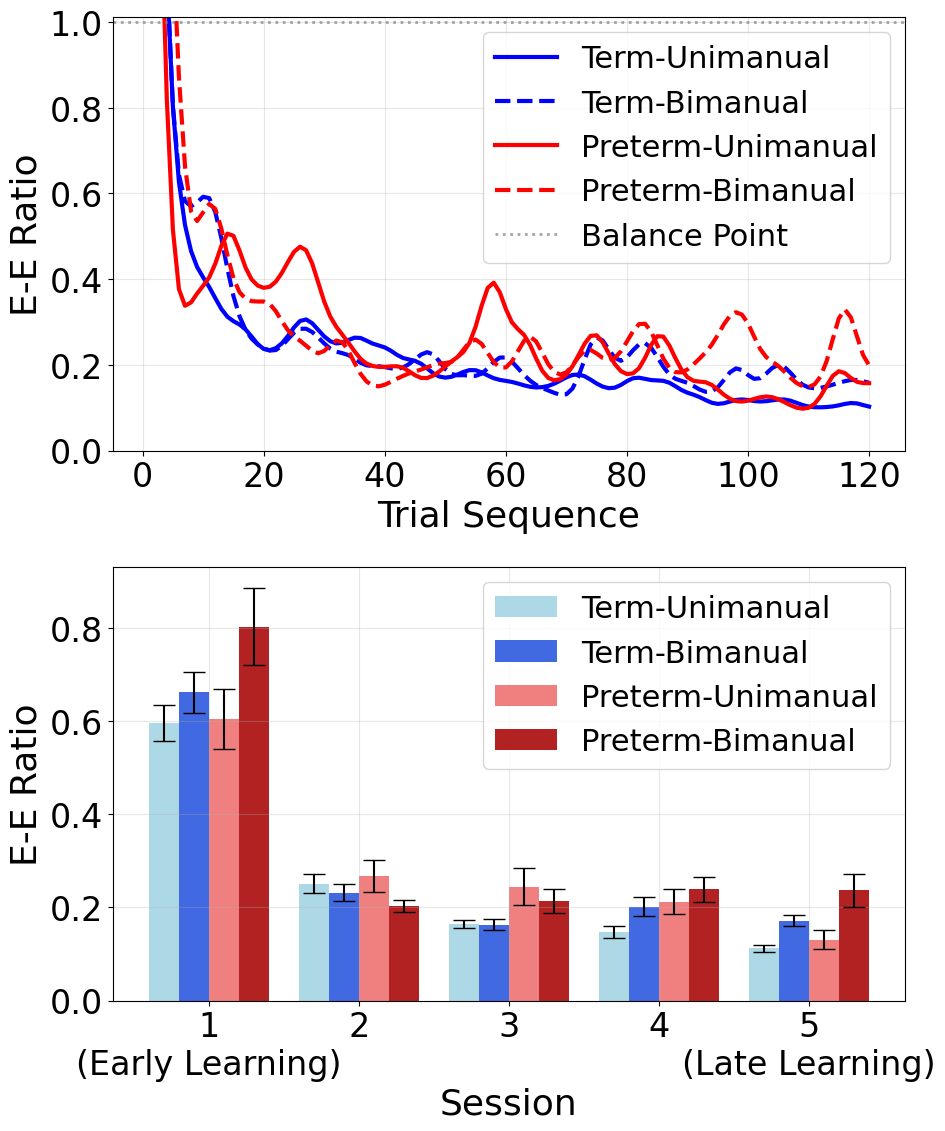

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec
import os

def create_motor_learning_visualizations(df_with_ratio, save_dir=None, dpi=300, font_size=24):
    """
    Create comprehensive visualizations for motor learning strategies using the pre-calculated
    exploration-exploitation ratio dataframe.
    
    Parameters:
    -----------
    df_with_ratio : pandas.DataFrame
        DataFrame with pre-calculated exploration-exploitation ratios and scores
        Must include: 'participant_id', 'task_type'/'task_label', 'Cohort',
                     'exploration_score', 'exploitation_score', 'exploration_exploitation_ratio',
                     'session_no', 'trial_seq' (or sequence number)
    save_dir : str, optional
        Directory to save figures. If None, figures are not saved.
    dpi : int, optional
        DPI for saved figures (default: 300)
    font_size : int, optional
        Base font size for all text elements (default: 24)
    
    Returns:
    --------
    dict
        Dictionary containing the figures and statistical results
    """
    # Set global font size
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 4,
        'axes.labelsize': font_size + 2,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size - 2,
        'figure.titlesize': font_size + 6
    })
    
    # Create a copy of the dataframe to work with
    df = df_with_ratio.copy()
    
    # Check if task_label exists, otherwise create it
    if 'task_label' not in df.columns and 'task_type' in df.columns:
        df['task_label'] = df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    # Create a combined group label for easier analysis
    df['group'] = df['Cohort'] + '-' + df['task_label']
    
    # Create a figure with subplots for visualizations - increased size for larger fonts
    fig = plt.figure(figsize=(10, 12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    
    # 1. Trial-wise exploration-exploitation ratio changes
    ax1 = plt.subplot(gs[0])  # First row for trial-wise ratio
    plot_trial_wise_ratio(df, ax1, font_size)
    
    # 2. Session-wise exploration-exploitation ratio mean
    ax2 = plt.subplot(gs[1])  # Second row for session comparison
    plot_session_comparison(df, ax2, font_size)
    
    # Run the statistical analyses
    ratio_stats = analyze_group_comparisons(df)
    phase_stats = analyze_early_late_comparisons(df)
    
    # Print the statistical results instead of plotting tables
    print_statistical_results(ratio_stats, phase_stats)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add overall title
    # fig.suptitle('Motor Learning Strategy Analysis', fontsize=font_size + 6, y=0.98)
    plt.subplots_adjust(top=0.95)
    
    # Save figures if save_dir is provided
    if save_dir is not None:
        save_motor_learning_plots(fig, ax1, ax2, df, save_dir, dpi, font_size)
    
    # Reset matplotlib parameters to default
    plt.rcdefaults()
    
    return {
        'figure': fig,
        'ratio_stats': ratio_stats,
        'phase_stats': phase_stats
    }

def save_motor_learning_plots(fig, ax1, ax2, df, save_dir, dpi, font_size):
    """
    Save the motor learning plots both combined and separately.
    
    Parameters:
    -----------
    fig : matplotlib.figure.Figure
        The combined figure
    ax1, ax2 : matplotlib.axes.Axes
        Individual axes objects
    df : pandas.DataFrame
        The dataframe with motor learning data
    save_dir : str
        Directory to save figures
    dpi : int
        DPI for saved figures
    font_size : int
        Base font size
    """
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Save combined figure
    combined_filename = "motor_learning_combined.png"
    combined_filepath = os.path.join(save_dir, combined_filename)
    fig.savefig(combined_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"Combined motor learning figure saved to: {combined_filepath}")
    
    # Save individual plots
    # 1. Trial-wise ratio plot
    fig1, ax1_single = plt.subplots(1, 1, figsize=(8, 6))
    plot_trial_wise_ratio(df, ax1_single, font_size)
    plt.tight_layout()
    
    trial_filename = "motor_learning_trial_wise.png"
    trial_filepath = os.path.join(save_dir, trial_filename)
    fig1.savefig(trial_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"Trial-wise ratio plot saved to: {trial_filepath}")
    plt.close(fig1)
    
    # 2. Session comparison plot
    fig2, ax2_single = plt.subplots(1, 1, figsize=(8, 6))
    plot_session_comparison(df, ax2_single, font_size)
    plt.tight_layout()
    
    session_filename = "motor_learning_session_comparison.png"
    session_filepath = os.path.join(save_dir, session_filename)
    fig2.savefig(session_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"Session comparison plot saved to: {session_filepath}")
    plt.close(fig2)

def print_statistical_results(ratio_stats, phase_stats):
    """
    Print statistical results in a formatted way.
    
    Parameters:
    -----------
    ratio_stats : list
        List of dictionaries containing group comparison statistics
    phase_stats : list
        List of dictionaries containing early-late comparison statistics
    """
    print("\n" + "="*80)
    print("STATISTICAL ANALYSIS RESULTS".center(80))
    print("="*80)
    
    print("\n" + "-"*80)
    print("GROUP COMPARISONS (OVERALL)".center(80))
    print("-"*80)
    
    for stat in ratio_stats:
        print(f"\nComparison: {stat['Comparison']}")
        print(f"Group 1: {stat['Group 1']} (N={stat['Group 1 N']:.0f})")
        print(f"  Mean ± 95% CI: {stat['Group 1 Mean']:.3f} ± {stat['Group 1 CI']:.3f}")
        print(f"Group 2: {stat['Group 2']} (N={stat['Group 2 N']:.0f})")
        print(f"  Mean ± 95% CI: {stat['Group 2 Mean']:.3f} ± {stat['Group 2 CI']:.3f}")
        print(f"t-statistic: {stat['t-statistic']:.3f}")
        print(f"p-value: {stat['p-value']:.4f}" + (f" *" if stat['p-value'] < 0.05 else ""))
    
    print("\n" + "-"*80)
    print("EARLY VS LATE PHASE COMPARISONS".center(80))
    print("-"*80)
    
    for stat in phase_stats:
        print(f"\nComparison: {stat['Comparison']}")
        print(f"Group 1: {stat['Group 1']} (N={stat['Group 1 N']:.0f})")
        print(f"  Mean ± 95% CI: {stat['Group 1 Mean']:.3f} ± {stat['Group 1 CI']:.3f}")
        print(f"Group 2: {stat['Group 2']} (N={stat['Group 2 N']:.0f})")
        print(f"  Mean ± 95% CI: {stat['Group 2 Mean']:.3f} ± {stat['Group 2 CI']:.3f}")
        print(f"t-statistic: {stat['t-statistic']:.3f}")
        print(f"p-value: {stat['p-value']:.4f}" + (f" *" if stat['p-value'] < 0.05 else ""))
    
    print("\n" + "="*80)

def plot_trial_wise_ratio(df, ax, font_size):
    """
    Plot trial-wise exploration-exploitation ratio changes for all four groups.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration-exploitation data
    ax : matplotlib.axes.Axes
        Axes to plot on
    font_size : int
        Base font size
    """
    # Define colors and line styles
    colors = {'Term': 'blue', 'Preterm': 'red'}
    line_styles = {'Unimanual': '-', 'Bimanual': '--'}
    
    # Make sure we're plotting all four groups
    for cohort in ['Term', 'Preterm']:
        for task in ['Unimanual', 'Bimanual']:
            # Check if this group exists in the data
            group_data = df[(df['Cohort'] == cohort) & (df['task_label'] == task)]
            if group_data.empty:
                print(f"Warning: No data found for {cohort}-{task}")
    
    # Group data by cohort, task_label, and trial_seq
    grouped_data = df.groupby(['Cohort', 'task_label', 'trial_seq'])['exploration_exploitation_ratio'].agg(
        ['mean', 'std', 'count']).reset_index()
    
    # Calculate standard error
    grouped_data['se'] = grouped_data['std'] / np.sqrt(grouped_data['count'])
    
    # Plot each group
    for cohort in ['Term', 'Preterm']:
        for task in ['Unimanual', 'Bimanual']:
            data = grouped_data[(grouped_data['Cohort'] == cohort) & (grouped_data['task_label'] == task)]
            
            if data.empty:
                print(f"No data to plot for {cohort}-{task}")
                continue
                
            # Sort by trial sequence
            data = data.sort_values('trial_seq')
            
            # Apply smoothing for better visualization
            smooth_means = gaussian_filter1d(data['mean'].values, sigma=2)
            
            # Plot the smoothed line with increased line width
            ax.plot(data['trial_seq'], smooth_means, 
                    label=f"{cohort}-{task}",
                    color=colors[cohort],
                    linestyle=line_styles[task],
                    linewidth=3)
            
            # Add confidence intervals
            # ax.fill_between(
            #     data['trial_seq'],
            #     smooth_means - 1.96 * data['se'],
            #     smooth_means + 1.96 * data['se'],
            #     alpha=0.2,
            #     color=colors[cohort]
            # )
    
    # Add a reference line at ratio=1 (equal exploration and exploitation)
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, linewidth=2, label='Balance Point')
    
    # Set labels and title with larger fonts
    # ax.set_title('Trial-wise Exploration-Exploitation Ratio Changes', 
    #             fontsize=font_size + 4, fontweight='bold')
    ax.set_xlabel('Trial Sequence', fontsize=font_size + 2)
    ax.set_ylabel('E-E Ratio', fontsize=font_size + 2)
    ax.legend(loc='best', fontsize=font_size - 2)
    ax.grid(True, alpha=0.3)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    
    # Set reasonable y-limits
    ratio_max = np.percentile(grouped_data['mean'].replace([np.inf, -np.inf], np.nan).dropna(), 95)  # 95th percentile to avoid outliers
    ax.set_ylim([0, min(5, ratio_max * 1.5)])  # Cap at 5 for readability

def plot_session_comparison(df, ax, font_size):
    """
    Create a bar chart showing session-wise exploration-exploitation ratio for all five sessions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration-exploitation data
    ax : matplotlib.axes.Axes
        Axes to plot on
    font_size : int
        Base font size
    """
    # Define colors for different groups
    group_colors = {
        'Term-Unimanual': 'lightblue',
        'Term-Bimanual': 'royalblue',
        'Preterm-Unimanual': 'lightcoral',
        'Preterm-Bimanual': 'firebrick'
    }
    
    # Group by session_no, Cohort, and task_label
    grouped_data = df.groupby(['session_no', 'Cohort', 'task_label'])['exploration_exploitation_ratio'].agg(
        ['mean', 'std', 'count']).reset_index()
    
    # Calculate standard error
    grouped_data['se'] = grouped_data['std'] / np.sqrt(grouped_data['count'])
    
    # Create a column for the combined group
    grouped_data['group'] = grouped_data['Cohort'] + '-' + grouped_data['task_label']
    
    # Get unique sessions
    sessions = sorted(grouped_data['session_no'].unique())
    
    # Get unique groups
    groups = ['Term-Unimanual', 'Term-Bimanual', 'Preterm-Unimanual', 'Preterm-Bimanual']
    
    # Set up bar positions
    bar_width = 0.2
    index = np.arange(len(sessions))
    offsets = [-1.5*bar_width, -0.5*bar_width, 0.5*bar_width, 1.5*bar_width]
    
    # Plot bars for each group
    for i, group in enumerate(groups):
        # Extract data for this group
        group_data = grouped_data[grouped_data['group'] == group]
        
        if group_data.empty:
            print(f"No data to plot for {group}")
            continue
        
        # Prepare data arrays
        means = []
        errors = []
        
        for session in sessions:
            session_data = group_data[group_data['session_no'] == session]
            if not session_data.empty:
                means.append(session_data['mean'].values[0])
                errors.append(session_data['se'].values[0])
            else:
                means.append(0)
                errors.append(0)
        
        # Plot bars with increased cap size
        ax.bar(index + offsets[i], means, bar_width, 
              label=group, color=group_colors[group], 
              yerr=errors, capsize=8)
    
    # Set x-axis labels and ticks with larger fonts
    ax.set_xlabel('Session', fontsize=font_size + 2)
    ax.set_ylabel('E-E Ratio', fontsize=font_size + 2)
    # ax.set_title('Session-wise Exploration-Exploitation Ratio', 
    #             fontsize=font_size + 4, fontweight='bold')
    ax.set_xticks(index)
    
    # Create session labels with session 1 as Early and session 5 as Late
    session_labels = []
    for session in sessions:
        if session == 1:
            session_labels.append(f"{session}\n(Early Learning)")
        elif session == 5:
            session_labels.append(f"{session}\n(Late Learning)")
        else:
            session_labels.append(str(session))
    
    ax.set_xticklabels(session_labels, fontsize=font_size)
    ax.legend(loc='best', fontsize=font_size - 2)
    ax.grid(True, alpha=0.3)
    
    # Increase tick label size
    ax.tick_params(axis='both', which='major', labelsize=font_size)

def analyze_group_comparisons(df):
    """
    Conduct statistical analysis comparing different groups.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration-exploitation data
        
    Returns:
    --------
    list
        List of dictionaries containing statistical results
    """
    ratio_stats = []
    
    # 1. Unimanual vs Bimanual comparison for each cohort
    for cohort in ['Term', 'Preterm']:
        uni_data = df[(df['Cohort'] == cohort) & (df['task_label'] == 'Unimanual')]['exploration_exploitation_ratio']
        bi_data = df[(df['Cohort'] == cohort) & (df['task_label'] == 'Bimanual')]['exploration_exploitation_ratio']
        
        if len(uni_data) > 1 and len(bi_data) > 1:
            t_stat, p_val = stats.ttest_ind(uni_data, bi_data, equal_var=False)
            
            # Calculate 95% confidence intervals
            uni_se = uni_data.std() / np.sqrt(len(uni_data))
            bi_se = bi_data.std() / np.sqrt(len(bi_data))
            uni_ci = 1.96 * uni_se
            bi_ci = 1.96 * bi_se
            
            ratio_stats.append({
                'Comparison': f'{cohort}: Unimanual vs Bimanual',
                'Group 1': 'Unimanual',
                'Group 1 Mean': uni_data.mean(),
                'Group 1 SD': uni_data.std(),
                'Group 1 CI': uni_ci,
                'Group 1 N': len(uni_data),
                'Group 2': 'Bimanual',
                'Group 2 Mean': bi_data.mean(),
                'Group 2 SD': bi_data.std(),
                'Group 2 CI': bi_ci,
                'Group 2 N': len(bi_data),
                't-statistic': t_stat,
                'p-value': p_val
            })
    
    # 2. Term vs Preterm comparison for each task
    for task in ['Unimanual', 'Bimanual']:
        term_data = df[(df['Cohort'] == 'Term') & (df['task_label'] == task)]['exploration_exploitation_ratio']
        preterm_data = df[(df['Cohort'] == 'Preterm') & (df['task_label'] == task)]['exploration_exploitation_ratio']
        
        if len(term_data) > 1 and len(preterm_data) > 1:
            t_stat, p_val = stats.ttest_ind(term_data, preterm_data, equal_var=False)
            
            # Calculate 95% confidence intervals
            term_se = term_data.std() / np.sqrt(len(term_data))
            preterm_se = preterm_data.std() / np.sqrt(len(preterm_data))
            term_ci = 1.96 * term_se
            preterm_ci = 1.96 * preterm_se
            
            ratio_stats.append({
                'Comparison': f'{task}: Term vs Preterm',
                'Group 1': 'Term',
                'Group 1 Mean': term_data.mean(),
                'Group 1 SD': term_data.std(),
                'Group 1 CI': term_ci,
                'Group 1 N': len(term_data),
                'Group 2': 'Preterm',
                'Group 2 Mean': preterm_data.mean(),
                'Group 2 SD': preterm_data.std(),
                'Group 2 CI': preterm_ci,
                'Group 2 N': len(preterm_data),
                't-statistic': t_stat,
                'p-value': p_val
            })
            
    return ratio_stats

def analyze_early_late_comparisons(df):
    """
    Conduct statistical analysis comparing early and late learning phases.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with exploration-exploitation data
        
    Returns:
    --------
    list
        List of dictionaries containing statistical results
    """
    phase_stats = []
    
    # Filter to only early (session 1) and late (session 5) sessions
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    
    # 1. Term vs Preterm comparison for each task and phase
    for task in ['Unimanual', 'Bimanual']:
        for phase_name in ['Early', 'Late']:
            term_data = phase_data[(phase_data['Cohort'] == 'Term') & 
                               (phase_data['task_label'] == task) & 
                               (phase_data['phase'] == phase_name)]['exploration_exploitation_ratio']
            
            preterm_data = phase_data[(phase_data['Cohort'] == 'Preterm') & 
                                  (phase_data['task_label'] == task) & 
                                  (phase_data['phase'] == phase_name)]['exploration_exploitation_ratio']
            
            if len(term_data) > 1 and len(preterm_data) > 1:
                t_stat, p_val = stats.ttest_ind(term_data, preterm_data, equal_var=False)
                
                # Calculate 95% confidence intervals
                term_se = term_data.std() / np.sqrt(len(term_data))
                preterm_se = preterm_data.std() / np.sqrt(len(preterm_data))
                term_ci = 1.96 * term_se
                preterm_ci = 1.96 * preterm_se
                
                phase_stats.append({
                    'Comparison': f'{task} - {phase_name} Phase: Term vs Preterm',
                    'Group 1': 'Term',
                    'Group 1 Mean': term_data.mean(),
                    'Group 1 SD': term_data.std(),
                    'Group 1 CI': term_ci,
                    'Group 1 N': len(term_data),
                    'Group 2': 'Preterm',
                    'Group 2 Mean': preterm_data.mean(),
                    'Group 2 SD': preterm_data.std(),
                    'Group 2 CI': preterm_ci,
                    'Group 2 N': len(preterm_data),
                    't-statistic': t_stat,
                    'p-value': p_val
                })
    
    # 2. Early vs Late comparison for each cohort and task
    for cohort in ['Term', 'Preterm']:
        for task in ['Unimanual', 'Bimanual']:
            early_data = phase_data[(phase_data['Cohort'] == cohort) & 
                                (phase_data['task_label'] == task) & 
                                (phase_data['phase'] == 'Early')]['exploration_exploitation_ratio']
            
            late_data = phase_data[(phase_data['Cohort'] == cohort) & 
                               (phase_data['task_label'] == task) & 
                               (phase_data['phase'] == 'Late')]['exploration_exploitation_ratio']
            
            if len(early_data) > 1 and len(late_data) > 1:
                t_stat, p_val = stats.ttest_ind(early_data, late_data, equal_var=False)
                
                # Calculate 95% confidence intervals
                early_se = early_data.std() / np.sqrt(len(early_data))
                late_se = late_data.std() / np.sqrt(len(late_data))
                early_ci = 1.96 * early_se
                late_ci = 1.96 * late_se
                
                phase_stats.append({
                    'Comparison': f'{cohort} - {task}: Early vs Late',
                    'Group 1': 'Early',
                    'Group 1 Mean': early_data.mean(),
                    'Group 1 SD': early_data.std(),
                    'Group 1 CI': early_ci,
                    'Group 1 N': len(early_data),
                    'Group 2': 'Late',
                    'Group 2 Mean': late_data.mean(),
                    'Group 2 SD': late_data.std(),
                    'Group 2 CI': late_ci,
                    'Group 2 N': len(late_data),
                    't-statistic': t_stat,
                    'p-value': p_val
                })
                
    return phase_stats


# Usage examples:

# 1. Display only (no saving)
# results = create_motor_learning_visualizations(df_with_ratio_progress)

# 2. Display and save all versions (combined + individual plots)
results = create_motor_learning_visualizations(df_with_ratio_progress, save_dir='./plots/motor_learning/')

# 3. Display and save with custom settings - saves 3 files:
#    - motor_learning_combined.png (both plots together)
#    - motor_learning_trial_wise.png (trial-wise ratio plot only) 
#    - motor_learning_session_comparison.png (session comparison plot only)
# results = create_motor_learning_visualizations(df_with_ratio_progress, 
#                                               save_dir='./motor_learning_plots',
#                                               dpi=600, 
#                                               font_size=24)

# plt.show()

In [ ]:
df_with_ratio_progress.to_csv("../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories_msl.csv", index=False)

In [ ]:
df_ratio_stats = pd.DataFrame(results['ratio_stats'])
df_phase_stats = pd.DataFrame(results['phase_stats'])
df_phase_stats

,Comparison,Group 1,Group 1 Mean,Group 1 SD,Group 1 CI,Group 1 N,Group 2,Group 2 Mean,Group 2 SD,Group 2 CI,Group 2 N,t-statistic,p-value
0,Unimanual - Early Phase: Term vs Preterm,Term,0.596567,1.333085,0.075426,1200,Preterm,0.605143,1.342922,0.126638,432,-0.114039,9.092370e-01
1,Unimanual - Late Phase: Term vs Preterm,Term,0.112221,0.253647,0.014351,1200,Preterm,0.130955,0.439499,0.041445,432,-0.837177,4.028648e-01
2,Bimanual - Early Phase: Term vs Preterm,Term,0.662417,1.535477,0.086878,1200,Preterm,0.803868,1.738750,0.163965,432,-1.494100,1.356082e-01
3,Bimanual - Late Phase: Term vs Preterm,Term,0.171847,0.412035,0.023313,1200,Preterm,0.237300,0.736458,0.069448,432,-1.751203,8.048814e-02
4,Term - Unimanual: Early vs Late,Early,0.596567,1.333085,0.075426,1200,Late,0.112221,0.253647,0.014351,1200,12.364199,2.918157e-33
5,Term - Bimanual: Early vs Late,Early,0.662417,1.535477,0.086878,1200,Late,0.171847,0.412035,0.023313,1200,10.689290,1.135307e-25
6,Preterm - Unimanual: Early vs Late,Early,0.605143,1.342922,0.126638,432,Late,0.130955,0.439499,0.041445,432,6.975051,9.290234e-12
7,Preterm - Bimanual: Early vs Late,Early,0.803868,1.738750,0.163965,432,Late,0.237300,0.736458,0.069448,432,6.236290,8.629512e-10


In [ ]:
df_ratio_stats = pd.DataFrame(results['ratio_stats'])
df_phase_stats = pd.DataFrame(results['phase_stats'])
df_phase_stats

,Comparison,Group 1,Group 1 Mean,Group 1 SD,Group 1 CI,Group 1 N,Group 2,Group 2 Mean,Group 2 SD,Group 2 CI,Group 2 N,t-statistic,p-value
0,Unimanual - Early Phase: Term vs Preterm,Term,0.596567,1.333085,0.075426,1200,Preterm,0.605143,1.342922,0.126638,432,-0.114039,9.092370e-01
1,Unimanual - Late Phase: Term vs Preterm,Term,0.112221,0.253647,0.014351,1200,Preterm,0.130955,0.439499,0.041445,432,-0.837177,4.028648e-01
2,Bimanual - Early Phase: Term vs Preterm,Term,0.662417,1.535477,0.086878,1200,Preterm,0.803868,1.738750,0.163965,432,-1.494100,1.356082e-01
3,Bimanual - Late Phase: Term vs Preterm,Term,0.171847,0.412035,0.023313,1200,Preterm,0.237300,0.736458,0.069448,432,-1.751203,8.048814e-02
4,Term - Unimanual: Early vs Late,Early,0.596567,1.333085,0.075426,1200,Late,0.112221,0.253647,0.014351,1200,12.364199,2.918157e-33
5,Term - Bimanual: Early vs Late,Early,0.662417,1.535477,0.086878,1200,Late,0.171847,0.412035,0.023313,1200,10.689290,1.135307e-25
6,Preterm - Unimanual: Early vs Late,Early,0.605143,1.342922,0.126638,432,Late,0.130955,0.439499,0.041445,432,6.975051,9.290234e-12
7,Preterm - Bimanual: Early vs Late,Early,0.803868,1.738750,0.163965,432,Late,0.237300,0.736458,0.069448,432,6.236290,8.629512e-10


In [ ]:
df_phase_stats.columns

Index(['Comparison', 'Group 1', 'Group 1 Mean', 'Group 1 SD', 'Group 1 N',
       'Group 2', 'Group 2 Mean', 'Group 2 SD', 'Group 2 N', 't-statistic',
       'p-value'],
      dtype='object')

In [ ]:
df_ratio_stats

,Comparison,Group 1,Group 1 Mean,Group 1 SD,Group 1 CI,Group 1 N,Group 2,Group 2 Mean,Group 2 SD,Group 2 CI,Group 2 N,t-statistic,p-value
0,Term: Unimanual vs Bimanual,Unimanual,0.254543,0.747682,0.018919,6000,Bimanual,0.286146,0.873810,0.022110,6000,-2.128639,0.033305
1,Preterm: Unimanual vs Bimanual,Unimanual,0.291969,0.848547,0.035785,2160,Bimanual,0.339377,0.947585,0.039962,2160,-1.732223,0.083306
2,Unimanual: Term vs Preterm,Term,0.254543,0.747682,0.018919,6000,Preterm,0.291969,0.848547,0.035785,2160,-1.812188,0.070044
3,Bimanual: Term vs Preterm,Term,0.286146,0.873810,0.022110,6000,Preterm,0.339377,0.947585,0.039962,2160,-2.284455,0.022403


## ANOVA test comparing Term vs Preterm groups and Early vs Late learning phases, combining data from both Unimanual and Bimanual tasks. 

In [ ]:
df_with_ratio_progress.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss', 'exploration_score',
       'exploitation_score', 'novelty', 'avg_similarity_to_window',
       'max_similarity_to_window', 'trial_seq', 'task_label',
       'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')

Sample sizes:
Cohort   Phase
Preterm  Early     864
         Late      864
Term     Early    2400
         Late     2400
dtype: int64

Descriptive Statistics:
    Cohort  Phase      mean       std  count     CI_95
0  Preterm  Early  0.489978  1.675015    864  0.111691
1  Preterm   Late  0.074944  0.298760    864  0.019921
2     Term  Early  0.469655  1.680319   2400  0.067227
3     Term   Late  0.056569  0.207361   2400  0.008296

Two-way ANOVA Results:
                         sum_sq      df           F        PR(>F)
C(Cohort)              0.475683     1.0    0.331025  5.650759e-01
C(Phase)             279.180285     1.0  194.279842  1.550595e-43
C(Cohort):C(Phase)     0.001204     1.0    0.000838  9.769052e-01
Residual            9374.993104  6524.0         NaN           NaN


/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_78502/1237531626.py:91: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.pointplot(


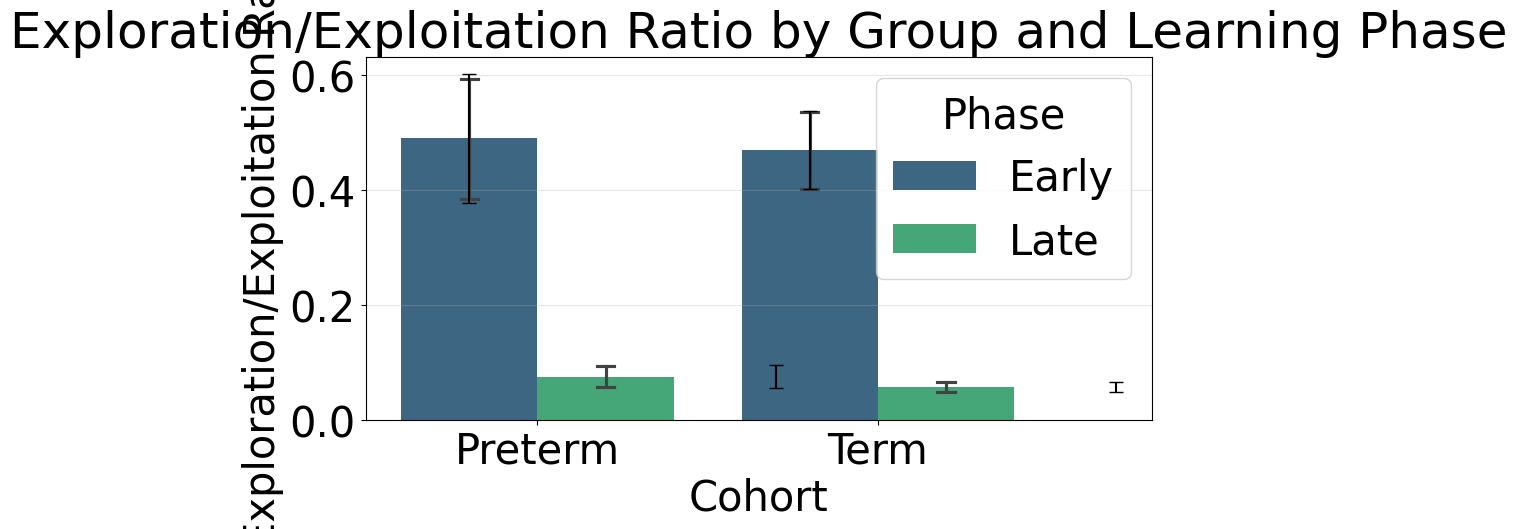

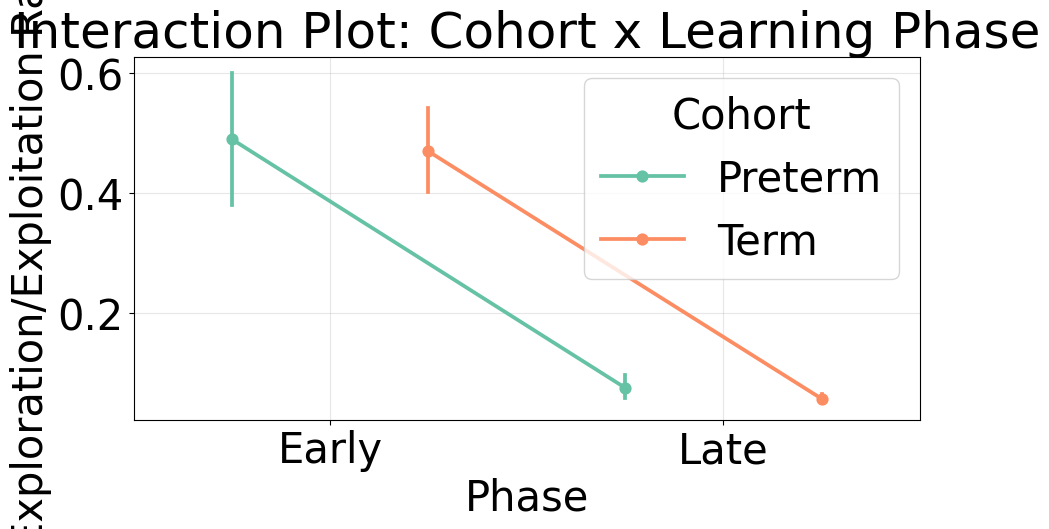


Effect Sizes (Partial Eta Squared):
                    partial_eta_sq
C(Cohort)             4.926988e-05
C(Phase)              2.891666e-02
C(Cohort):C(Phase)    1.247448e-07
Residual              9.710339e-01


In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import seaborn as sns

def perform_two_way_anova(df):
    """
    Perform a two-way ANOVA test between Term and Preterm groups, comparing Early vs Late learning phases
    while combining Unimanual and Bimanual tasks.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with exploration-exploitation data
    
    Returns:
    --------
    tuple
        ANOVA results table and descriptive statistics
    """
    # Filter to only include early (session 1) and late (session 5) sessions
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['Phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    
    # Create a new DataFrame for ANOVA
    anova_df = phase_data[['Cohort', 'Phase', 'exploration_exploitation_ratio']].copy()
    
    # Print sample sizes for each group
    print("Sample sizes:")
    print(anova_df.groupby(['Cohort', 'Phase']).size())
    
    # Calculate descriptive statistics
    desc_stats = anova_df.groupby(['Cohort', 'Phase'])['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Calculate 95% CI
    desc_stats['CI_95'] = 1.96 * desc_stats['std'] / np.sqrt(desc_stats['count'])
    
    print("\nDescriptive Statistics:")
    print(desc_stats)
    
    # Run the two-way ANOVA
    model = ols('exploration_exploitation_ratio ~ C(Cohort) * C(Phase)', data=anova_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    print("\nTwo-way ANOVA Results:")
    print(anova_table)
    
    # Create a visualization
    plt.figure(figsize=(10, 6))
    
    # Create a grouped bar plot
    ax = sns.barplot(
        x='Cohort', 
        y='exploration_exploitation_ratio', 
        hue='Phase', 
        data=anova_df,
        capsize=0.1,
        palette='viridis'
    )
    
    # Add error bars representing 95% confidence intervals
    for i, group in enumerate(desc_stats.itertuples()):
        # Calculate position on x-axis
        if group.Phase == 'Early':
            pos = i/2 - 0.2
        else:
            pos = i/2 + 0.2
            
        # Add error bars
        plt.errorbar(
            x=pos, 
            y=group.mean,
            yerr=group.CI_95,
            fmt='none', 
            c='black',
            capsize=5
        )
    
    plt.title('Exploration/Exploitation Ratio by Group and Learning Phase')
    plt.ylabel('Exploration/Exploitation Ratio')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    # Create an interaction plot
    plt.figure(figsize=(10, 6))
    sns.pointplot(
        x='Phase', 
        y='exploration_exploitation_ratio', 
        hue='Cohort', 
        data=anova_df,
        dodge=0.5,
        ci=95,
        palette='Set2'
    )
    plt.title('Interaction Plot: Cohort x Learning Phase')
    plt.ylabel('Exploration/Exploitation Ratio')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    return anova_table, desc_stats

# Example usage
anova_results, descriptive_stats = perform_two_way_anova(df_with_ratio_progress)
plt.show()

# Bonus: Add calculation of effect sizes
def calculate_effect_sizes(anova_results, df):
    """
    Calculate effect sizes (partial eta squared) from ANOVA results
    """
    # Filter data for ANOVA
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['Phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    anova_df = phase_data[['Cohort', 'Phase', 'exploration_exploitation_ratio']].copy()
    
    # Calculate total sum of squares
    total_ss = anova_df['exploration_exploitation_ratio'].var() * (len(anova_df) - 1)
    
    # Calculate partial eta squared for each effect
    anova_results_with_effect = anova_results.copy()
    anova_results_with_effect['partial_eta_sq'] = anova_results['sum_sq'] / (anova_results['sum_sq'] + anova_results['sum_sq'].sum() - anova_results['sum_sq'])
    
    print("\nEffect Sizes (Partial Eta Squared):")
    print(anova_results_with_effect[['partial_eta_sq']])
    
    return anova_results_with_effect

effect_sizes = calculate_effect_sizes(anova_results, df_with_ratio_progress)

## Three-way ANOVA Test

Sample sizes:
Cohort   Phase  Task_Type
Preterm  Early  Bimanual      432
                Unimanual     432
         Late   Bimanual      432
                Unimanual     432
Term     Early  Bimanual     1200
                Unimanual    1200
         Late   Bimanual     1200
                Unimanual    1200
dtype: int64

Descriptive Statistics:
    Cohort  Phase  Task_Type      mean       std  count     CI_95
0  Preterm  Early   Bimanual  0.490134  1.668670    432  0.157356
1  Preterm  Early  Unimanual  0.489822  1.683271    432  0.158733
2  Preterm   Late   Bimanual  0.095342  0.343257    432  0.032369
3  Preterm   Late  Unimanual  0.054547  0.245076    432  0.023111
4     Term  Early   Bimanual  0.483390  1.720980   1200  0.097374
5     Term  Early  Unimanual  0.455921  1.639253   1200  0.092749
6     Term   Late   Bimanual  0.072380  0.251633   1200  0.014237
7     Term   Late  Unimanual  0.040759  0.149040   1200  0.008433

Three-way ANOVA Results:
                              

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_78502/1322562352.py:62: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(
/Users/mdraihanmia/Ubicomp/PMNL/R03 Project/Analysis/MotorVariability/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/mdraihanmia/Ubicomp/PMNL/R03 Project/Analysis/MotorVariability/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  func(*plot_args, **plot_kwargs)


<Figure size 1400x600 with 0 Axes>

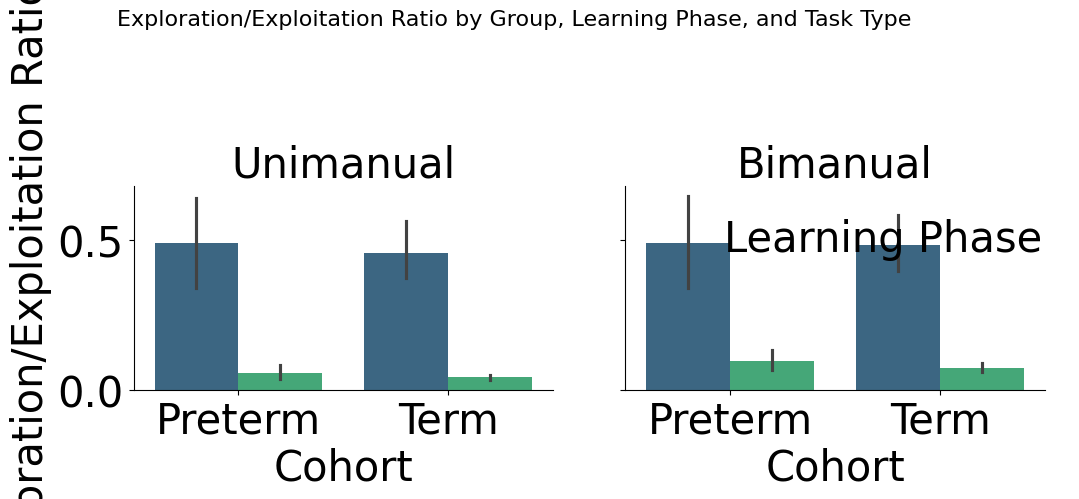

<Figure size 1400x600 with 0 Axes>

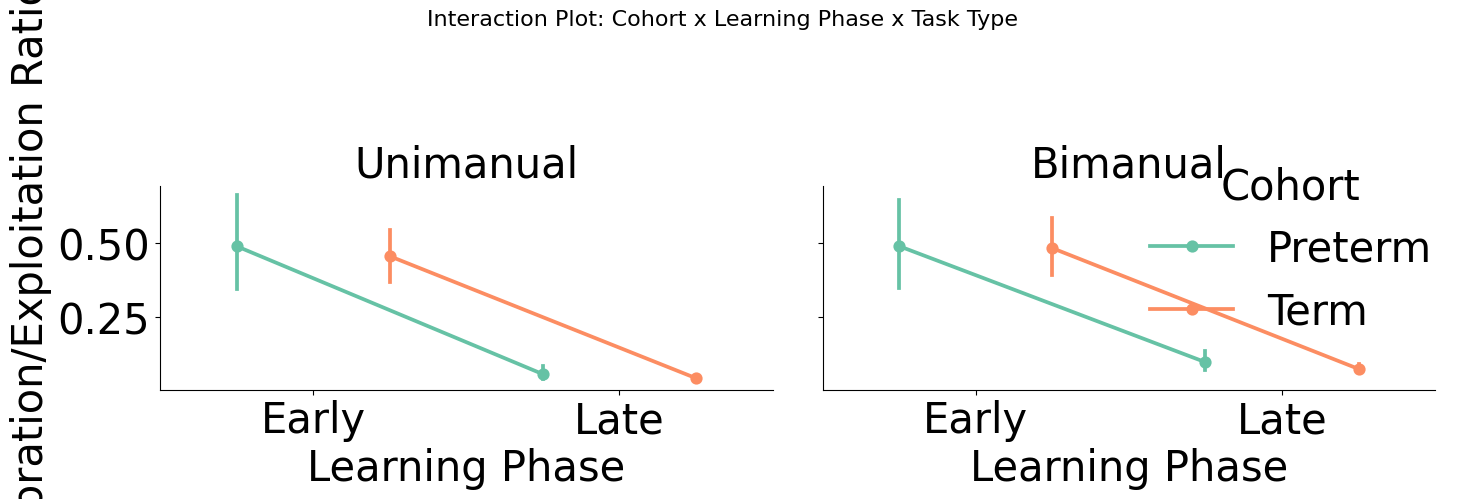


Effect Sizes (Partial Eta Squared):
                                 partial_eta_sq
C(Cohort)                          4.926988e-05
C(Phase)                           2.891666e-02
C(Task_Type)                       1.247396e-04
C(Cohort):C(Phase)                 1.247448e-07
C(Cohort):C(Task_Type)             2.659435e-06
C(Phase):C(Task_Type)              8.011761e-06
C(Cohort):C(Phase):C(Task_Type)    1.085687e-05
Residual                           9.708877e-01

Effect Size Interpretation:
                            Effect    Partial η² Interpretation
0                        C(Cohort)  4.926988e-05     Negligible
1                         C(Phase)  2.891666e-02          Small
2                     C(Task_Type)  1.247396e-04     Negligible
3               C(Cohort):C(Phase)  1.247448e-07     Negligible
4           C(Cohort):C(Task_Type)  2.659435e-06     Negligible
5            C(Phase):C(Task_Type)  8.011761e-06     Negligible
6  C(Cohort):C(Phase):C(Task_Type)  1.085687e-05     N

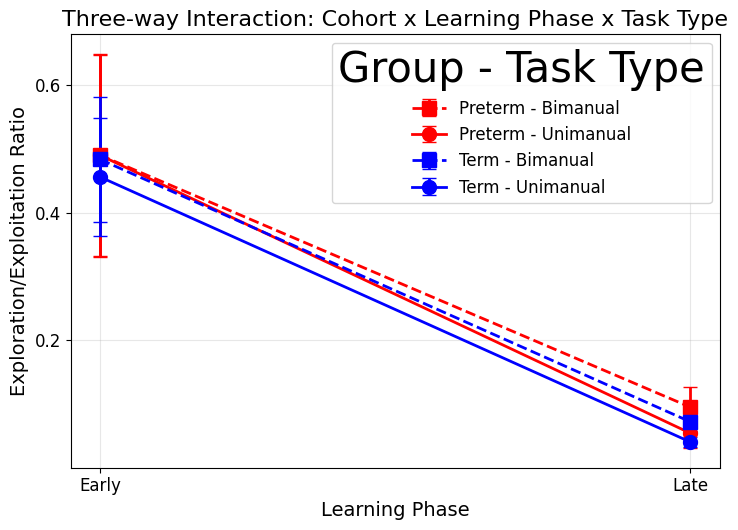

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import seaborn as sns

def perform_three_way_anova(df):
    """
    Perform a three-way ANOVA test between Term and Preterm groups, comparing Early vs Late learning phases,
    and including task_type (Unimanual vs Bimanual) as a factor.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with exploration-exploitation data
    
    Returns:
    --------
    tuple
        ANOVA results table and descriptive statistics
    """
    # Filter to only include early (session 1) and late (session 5) sessions
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['Phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    
    # Add task type as a categorical variable
    phase_data['Task_Type'] = phase_data['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    # Create a new DataFrame for ANOVA
    anova_df = phase_data[['Cohort', 'Phase', 'Task_Type', 'exploration_exploitation_ratio']].copy()
    
    # Print sample sizes for each group
    print("Sample sizes:")
    print(anova_df.groupby(['Cohort', 'Phase', 'Task_Type']).size())
    
    # Calculate descriptive statistics
    desc_stats = anova_df.groupby(['Cohort', 'Phase', 'Task_Type'])['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Calculate 95% CI
    desc_stats['CI_95'] = 1.96 * desc_stats['std'] / np.sqrt(desc_stats['count'])
    
    print("\nDescriptive Statistics:")
    print(desc_stats)
    
    # Run the three-way ANOVA with all interactions
    model = ols('exploration_exploitation_ratio ~ C(Cohort) * C(Phase) * C(Task_Type)', data=anova_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    print("\nThree-way ANOVA Results:")
    print(anova_table)
    
    # Create visualizations
    
    # Plot 1: Bar plot separated by task type
    plt.figure(figsize=(14, 6))
    
    # Create a grouped bar plot with facets for task type
    g = sns.catplot(
        x='Cohort', 
        y='exploration_exploitation_ratio', 
        hue='Phase',
        col='Task_Type',
        data=anova_df,
        kind='bar',
        height=5, 
        aspect=0.8,
        palette='viridis',
        ci=95,
        legend=False
    )
    
    g.set_axis_labels("Cohort", "Exploration/Exploitation Ratio")
    g.set_titles("{col_name}")
    g.add_legend(title="Learning Phase")
    g.fig.suptitle('Exploration/Exploitation Ratio by Group, Learning Phase, and Task Type', 
                  fontsize=16, y=1.05)
    
    plt.tight_layout()
    
    # Plot 2: Interaction plot for all three factors
    plt.figure(figsize=(14, 6))
    
    # Create separate interaction plots for each task type
    g = sns.FacetGrid(anova_df, col='Task_Type', height=5, aspect=1.2)
    g.map_dataframe(
        sns.pointplot, 
        x='Phase', 
        y='exploration_exploitation_ratio', 
        hue='Cohort',
        dodge=0.5,
        ci=95,
        palette='Set2'
    )
    
    g.set_axis_labels("Learning Phase", "Exploration/Exploitation Ratio")
    g.set_titles("{col_name}")
    g.add_legend(title="Cohort")
    g.fig.suptitle('Interaction Plot: Cohort x Learning Phase x Task Type', 
                  fontsize=16, y=1.05)
    
    plt.tight_layout()
    
    return anova_table, desc_stats

# Example usage
anova_results, descriptive_stats = perform_three_way_anova(df_with_ratio_progress)
plt.show()

def calculate_effect_sizes(anova_results, df):
    """
    Calculate effect sizes (partial eta squared) from ANOVA results
    including the task_type factor
    """
    # Filter data for ANOVA
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['Phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    phase_data['Task_Type'] = phase_data['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    anova_df = phase_data[['Cohort', 'Phase', 'Task_Type', 'exploration_exploitation_ratio']].copy()
    
    # Calculate total sum of squares
    total_ss = anova_df['exploration_exploitation_ratio'].var() * (len(anova_df) - 1)
    
    # Calculate partial eta squared for each effect
    anova_results_with_effect = anova_results.copy()
    anova_results_with_effect['partial_eta_sq'] = anova_results['sum_sq'] / (anova_results['sum_sq'] + anova_results['sum_sq'].sum() - anova_results['sum_sq'])
    
    print("\nEffect Sizes (Partial Eta Squared):")
    print(anova_results_with_effect[['partial_eta_sq']])
    
    # Create a table of effect size interpretations
    effect_sizes = anova_results_with_effect['partial_eta_sq'].copy()
    
    interpretation = []
    for eta_sq in effect_sizes:
        if eta_sq < 0.01:
            interpretation.append('Negligible')
        elif eta_sq < 0.06:
            interpretation.append('Small')
        elif eta_sq < 0.14:
            interpretation.append('Medium')
        else:
            interpretation.append('Large')
    
    effect_table = pd.DataFrame({
        'Effect': anova_results_with_effect.index,
        'Partial η²': effect_sizes.values,
        'Interpretation': interpretation
    })
    
    print("\nEffect Size Interpretation:")
    print(effect_table)
    
    return anova_results_with_effect, effect_table

effect_sizes, effect_table = calculate_effect_sizes(anova_results, df_with_ratio_progress)

def plot_three_way_interaction(df):
    """
    Create a comprehensive visualization of the three-way interaction
    """
    # Filter to only include early (session 1) and late (session 5) sessions
    phase_data = df[df['session_no'].isin([1, 5])].copy()
    phase_data['Phase'] = phase_data['session_no'].map({1: 'Early', 5: 'Late'})
    phase_data['Task_Type'] = phase_data['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    # Create a new DataFrame for visualization
    plot_df = phase_data[['Cohort', 'Phase', 'Task_Type', 'exploration_exploitation_ratio']].copy()
    
    # Calculate means and confidence intervals
    grouped = plot_df.groupby(['Cohort', 'Phase', 'Task_Type'])['exploration_exploitation_ratio']
    stats = grouped.agg(['mean', 'count', 'std']).reset_index()
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    stats['ci_95'] = stats['sem'] * 1.96
    
    # Create a comprehensive interaction plot
    plt.figure(figsize=(8, 6))
    
    # Define color palette
    colors = {'Term': 'blue', 'Preterm': 'red'}
    markers = {'Unimanual': 'o', 'Bimanual': 's'}
    linestyles = {'Unimanual': '-', 'Bimanual': '--'}
    
    # Plot each combination
    for cohort in stats['Cohort'].unique():
        for task in stats['Task_Type'].unique():
            subset = stats[(stats['Cohort'] == cohort) & (stats['Task_Type'] == task)]
            
            plt.errorbar(
                x=subset['Phase'],
                y=subset['mean'],
                yerr=subset['ci_95'],
                label=f"{cohort} - {task}",
                color=colors[cohort],
                marker=markers[task],
                linestyle=linestyles[task],
                markersize=10,
                capsize=5,
                linewidth=2
            )
    
    plt.title('Three-way Interaction: Cohort x Learning Phase x Task Type', fontsize=16)
    plt.xlabel('Learning Phase', fontsize=14)
    plt.ylabel('Exploration/Exploitation Ratio', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(title='Group - Task Type', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    return plt.gcf()

interaction_plot = plot_three_way_interaction(df_with_ratio_progress)
plt.show()

In [ ]:
df_with_ratio_progress['normalized_trajectory'] = df_with_ratio_progress['normalized_trajectory'].apply(lambda x: np.array(x))
df_with_ratio_progress['normalized_trajectory']

0        [[ 0.00000000e+00  0.00000000e+00  1.60000000e...
1        [[ 0.00000000e+00  0.00000000e+00  1.00000000e...
2        [[ 0.00000000e+00  0.00000000e+00  0.00000000e...
3        [[ 0.00000000e+00  0.00000000e+00  1.00000000e...
4        [[ 0.00000000e+00  0.00000000e+00  0.00000000e...
                               ...                        
16315    [[ 0.00000000e+00  0.00000000e+00  1.20000000e...
16316    [[ 0.00000000e+00  0.00000000e+00  1.20000000e...
16317    [[ 0.00000000e+00  0.00000000e+00  3.70000000e...
16318    [[ 0.00000000e+00  0.00000000e+00  2.80000000e...
16319    [[ 0.00000000e+00  0.00000000e+00  3.80000000e...
Name: normalized_trajectory, Length: 16320, dtype: object

In [ ]:
df_ratio_stats

,Comparison,Group 1,Group 1 Mean,Group 1 SD,Group 1 N,Group 2,Group 2 Mean,Group 2 SD,Group 2 N,t-statistic,p-value
0,Term: Unimanual vs Bimanual,Unimanual,0.254543,0.747682,6000,Bimanual,0.286146,0.873810,6000,-2.128639,0.033305
1,Preterm: Unimanual vs Bimanual,Unimanual,0.291969,0.848547,2160,Bimanual,0.339377,0.947585,2160,-1.732223,0.083306
2,Unimanual: Term vs Preterm,Term,0.254543,0.747682,6000,Preterm,0.291969,0.848547,2160,-1.812188,0.070044
3,Bimanual: Term vs Preterm,Term,0.286146,0.873810,6000,Preterm,0.339377,0.947585,2160,-2.284455,0.022403



                          STATISTICAL ANALYSIS RESULTS                          

--------------------------------------------------------------------------------
                          GROUP COMPARISONS (OVERALL)                           
--------------------------------------------------------------------------------

Comparison: Term: Unimanual vs Bimanual
Group 1: Unimanual (N=6000)
  Mean ± SD: 0.255 ± 0.748
Group 2: Bimanual (N=6000)
  Mean ± SD: 0.286 ± 0.874
t-statistic: -2.129
p-value: 0.0333 *

Comparison: Preterm: Unimanual vs Bimanual
Group 1: Unimanual (N=2160)
  Mean ± SD: 0.292 ± 0.849
Group 2: Bimanual (N=2160)
  Mean ± SD: 0.339 ± 0.948
t-statistic: -1.732
p-value: 0.0833

Comparison: Unimanual: Term vs Preterm
Group 1: Term (N=6000)
  Mean ± SD: 0.255 ± 0.748
Group 2: Preterm (N=2160)
  Mean ± SD: 0.292 ± 0.849
t-statistic: -1.812
p-value: 0.0700

Comparison: Bimanual: Term vs Preterm
Group 1: Term (N=6000)
  Mean ± SD: 0.286 ± 0.874
Group 2: Preterm (N=2160)
  M

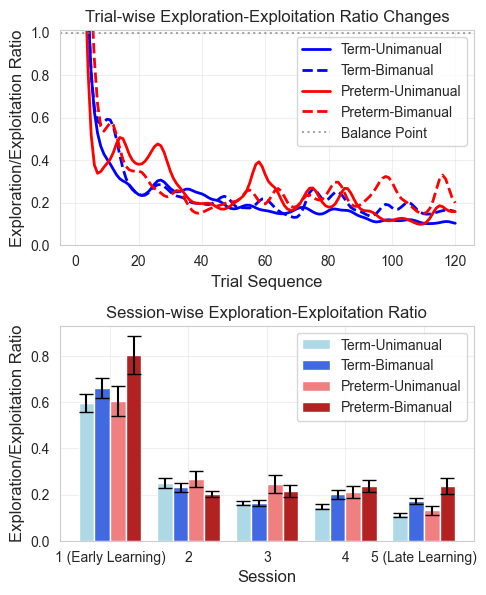


Significant findings in group comparisons:
- Term: Unimanual vs Bimanual: p=0.0333
  Unimanual: 0.255 ± 0.748
  Bimanual: 0.286 ± 0.874
- Bimanual: Term vs Preterm: p=0.0224
  Term: 0.286 ± 0.874
  Preterm: 0.339 ± 0.948

Significant findings in early vs late learning:
- Term - Unimanual: Early vs Late: p=0.0000
  Early: 0.597 ± 1.333
  Late: 0.112 ± 0.254
- Term - Bimanual: Early vs Late: p=0.0000
  Early: 0.662 ± 1.535
  Late: 0.172 ± 0.412
- Preterm - Unimanual: Early vs Late: p=0.0000
  Early: 0.605 ± 1.343
  Late: 0.131 ± 0.439
- Preterm - Bimanual: Early vs Late: p=0.0000
  Early: 0.804 ± 1.739
  Late: 0.237 ± 0.736


In [ ]:
# Create the visualizations and statistical analyses
results = create_motor_learning_visualizations(df_with_ratio)

# The results dictionary contains:
# - 'figure': The matplotlib figure with all visualizations
# - 'ratio_stats': Statistical comparison results between different groups
# - 'phase_stats': Statistical comparison results for early vs late learning phases

# Display the figure
plt.show()

# If you want to save the figure
# results['figure'].savefig('motor_learning_analysis.png', dpi=300, bbox_inches='tight')

# Print a summary of significant findings
print("\nSignificant findings in group comparisons:")
for stat in results['ratio_stats']:
    if stat['p-value'] < 0.05:
        print(f"- {stat['Comparison']}: p={stat['p-value']:.4f}")
        print(f"  {stat['Group 1']}: {stat['Group 1 Mean']:.3f} ± {stat['Group 1 SD']:.3f}")
        print(f"  {stat['Group 2']}: {stat['Group 2 Mean']:.3f} ± {stat['Group 2 SD']:.3f}")

print("\nSignificant findings in early vs late learning:")
for stat in results['phase_stats']:
    if stat['p-value'] < 0.05:
        print(f"- {stat['Comparison']}: p={stat['p-value']:.4f}")
        print(f"  {stat['Group 1']}: {stat['Group 1 Mean']:.3f} ± {stat['Group 1 SD']:.3f}")
        print(f"  {stat['Group 2']}: {stat['Group 2 Mean']:.3f} ± {stat['Group 2 SD']:.3f}")


In [ ]:
results

{'figure': <Figure size 2000x2500 with 5 Axes>,
 'ratio_stats': [{'Comparison': 'Preterm: Unimanual vs Bimanual',
   'Group 1': 'Unimanual',
   'Group 1 Mean': 0.35983776374611665,
   'Group 1 SD': 2.6901852587592945,
   'Group 1 N': 120,
   'Group 2': 'Bimanual',
   'Group 2 Mean': 0.5194136214456385,
   'Group 2 SD': 2.707420074763577,
   'Group 2 N': 120,
   't-statistic': -0.4580042078351511,
   'p-value': 0.6473673146016787}],
 'phase_stats': [{'Comparison': 'Preterm - Unimanual: Early vs Late',
   'Group 1': 'Early',
   'Group 1 Mean': 1.4031979428170283,
   'Group 1 SD': 5.996579661881664,
   'Group 1 N': 24,
   'Group 2': 'Late',
   'Group 2 Mean': 0.12494836197601422,
   'Group 2 SD': 0.22184547952525793,
   'Group 2 N': 24,
   't-statistic': 1.0435678138455413,
   'p-value': 0.30750123084071873},
  {'Comparison': 'Preterm - Bimanual: Early vs Late',
   'Group 1': 'Early',
   'Group 1 Mean': 1.7451369372227992,
   'Group 1 SD': 5.975274899345748,
   'Group 1 N': 24,
   'Group 

## Single Participant Embeddings Visualization

In [32]:
import numpy as np
import ast

def normalize_trajectory_3d(trajectory, time_sequence, target_position=np.array([1.0, 0.0])):
    """
    Normalize trajectory spatially while preserving original time.
    
    Args:
        trajectory: numpy array of shape (num_points, 2) containing x,y coordinates
        time_sequence: numpy array of timestamps in milliseconds for each point
        target_position: desired end position for all trajectories (default: [1,0])
    
    Returns:
        Normalized 3D trajectory (x, y, time_in_seconds)
    """
    # Convert time from milliseconds to seconds
    time_sequence_seconds = time_sequence / 1000.0
    
    # Spatial normalization
    start_pos = trajectory[0]
    centered = trajectory - start_pos
    
    # Get current target position after centering
    current_target = centered[-1]
    
    # Calculate rotation angle to align with desired target
    current_angle = np.arctan2(current_target[1], current_target[0])
    desired_angle = np.arctan2(target_position[1], target_position[0])
    rotation_angle = desired_angle - current_angle
    
    # Create rotation matrix
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    rotation_matrix = np.array([[cos_theta, -sin_theta],
                              [sin_theta, cos_theta]])
    
    # Rotate trajectory
    rotated = np.dot(centered, rotation_matrix.T)
    
    # Scale to match target length
    current_length = np.linalg.norm(rotated[-1])
    target_length = np.linalg.norm(target_position)
    scale_factor = target_length / current_length if current_length > 0 else 1
    
    normalized_spatial = rotated * scale_factor
    
    # Create 3D trajectory with time in seconds
    trajectory_3d = np.column_stack((normalized_spatial, time_sequence_seconds))
    
    return trajectory_3d

def normalize_trajectory_sequence_3d(path, time_diff_ms, target_position=np.array([1.0, 0.0]), target_length=512):
    """
    Normalize a trajectory into 3D (x, y, time_in_seconds).
    
    Args:
        path: trajectory coordinates as string or numpy array
        time_diff_ms: time differences in milliseconds
        target_position: desired end position (default: [1,0])
        target_length: desired number of points after resampling (default: 100)
    
    Returns:
        Normalized 3D trajectory with time in seconds
    """
    # Parse input trajectory
    trajectory = np.array(eval(path) if isinstance(path, str) else path)
    
    # Parse time sequence
    time_sequence = np.array(eval(time_diff_ms) if isinstance(time_diff_ms, str) else time_diff_ms)
    
    norm_traj_3d = np.array([])
    
    if isinstance(trajectory, np.ndarray) and trajectory.size > 0 and not np.all(trajectory == 0):
        # Normalize to 3D with time in seconds
        norm_traj_3d = normalize_trajectory_3d(trajectory, time_sequence, target_position)
        
        # Optional resampling (only for spatial coordinates)
        if target_length is not None and target_length > 2:
            t = np.linspace(0, 1, target_length)
            t_original = np.linspace(0, 1, len(norm_traj_3d))
            
            # Resample spatial coordinates
            resampled_spatial = np.vstack([
                np.interp(t, t_original, norm_traj_3d[:, 0]),
                np.interp(t, t_original, norm_traj_3d[:, 1])
            ]).T
            
            # Resample time to maintain correspondence
            resampled_time = np.interp(t, t_original, norm_traj_3d[:, 2])
            
            norm_traj_3d = np.column_stack((resampled_spatial, resampled_time))
    
    return norm_traj_3d

# Example usage:
# normalized_traj = normalize_trajectory_sequence_3d(
#     path=path_data,
#     time_diff_ms=time_diff_ms_data
# )

In [33]:
# df_with_ratio_progress = df
df_with_ratio_progress["normalized_trajectory"] = df_with_ratio_progress.apply(lambda x: normalize_trajectory_sequence_3d(x['path'], x['time_diff_ms']), axis=1)

In [ ]:
df_with_ratio_progress[['participant_id', 'session_no', 'task_type', 'trial_no', 'exploration_score',
       'exploitation_score','exploration_exploitation_ratio']].to_csv("children_score.csv", index=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec
import os

def calculate_similarity_scores(embeddings):
    """
    Calculate similarity scores between trajectory embeddings.
    
    Args:
        embeddings: numpy array of shape (n_trials, embedding_dim)
    
    Returns:
        Dictionary containing similarity scores
    """
    scores = []
    
    for i in range(len(embeddings)-1):
        current_embedding = embeddings[i]
        next_embedding = embeddings[i+1]
        
        # Similarity Score: cosine similarity between consecutive embeddings
        similarity = np.dot(current_embedding, next_embedding) / (
            np.linalg.norm(current_embedding) * np.linalg.norm(next_embedding))
        
        # Consistency Score: how similar to mean of previous trials
        previous_mean = np.mean(embeddings[:i+1], axis=0)
        consistency = np.dot(next_embedding, previous_mean) / (
            np.linalg.norm(next_embedding) * np.linalg.norm(previous_mean))
        
        scores.append({
            'trial_pair': (i, i+1),
            'similarity_score': similarity,
            'consistency_score': consistency
        })
    
    return scores

def plot_trajectories_with_similarity(df, participant_id, task_type="Unimanual", session_no=1, embedding_column='embedding', day=1, save_path=None):
    # Set font size to 30 for all matplotlib text
    plt.rcParams.update({'font.size': 30})
    
    # Filter data
    task = 0 if task_type=="Unimanual" else 1
    participant_data = df[(df['participant_id'] == participant_id) 
                          & (df['task_type'] == task) & (df['session_no'] == session_no)]
    
    # Create figure with four subplots - increased figure size to accommodate larger fonts
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5.5))
    
    # Plot original paths
    for _, trial in participant_data.iterrows():
        if isinstance(trial['path'], str):
            path = eval(trial['path'])
        else:
            path = trial['path']
            
        path = np.array(path)
        ax1.plot(path[:, 0], path[:, 1], '-', linewidth=3, alpha=0.7)
        ax1.plot(trial['start_point_x'], trial['start_point_y'], 'go', markersize=12, markeredgewidth=2, markeredgecolor='black')
        ax1.plot(trial['target_point_x'], trial['target_point_y'], 'ro', markersize=12, markeredgewidth=2, markeredgecolor='black')
    
    ax1.set_title(f'Original', fontsize=30)
    ax1.set_xlabel('X', fontsize=30)
    ax1.set_ylabel('Y', fontsize=30)
    ax1.tick_params(axis='both', which='major', labelsize=26)
    # ax1.set_xlim(-450,450)
    # ax1.set_ylim(-450,450)

    ax1.grid(True)
    ax1.axis('equal')
    
    
    # Plot normalized trajectories
    for _, trial in participant_data.iterrows():
        norm_traj = np.array(trial['normalized_trajectory'])
        ax2.plot(norm_traj[:, 0], norm_traj[:, 1], '-', linewidth=3, alpha=0.7)
        ax2.plot(0, 0, 'go', markersize=12, markeredgewidth=2, markeredgecolor='black')
        ax2.plot(norm_traj[-1, 0], norm_traj[-1, 1], 'ro', markersize=12, markeredgewidth=2, markeredgecolor='black')
    
    ax2.set_title(f'Normalized Trajectories', fontsize=30)
    ax2.set_xlabel('X', fontsize=30)
    ax2.set_ylabel('Y', fontsize=30)
    ax2.tick_params(axis='both', which='major', labelsize=26)
    ax2.grid(True)
    ax2.axis('equal')
    
    # Get participant data across all sessions for the embedding analysis
    all_participant_data = df[(df['participant_id'] == participant_id) & (df['task_type'] == task)]
    embeddings = np.stack(all_participant_data[embedding_column].values)
    session_info = all_participant_data['session_no'].values
    
    # Apply t-SNE for dimensionality reduction on embeddings
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    tsne_result = tsne.fit_transform(embeddings)
    
    # Create a colormap for visualizing sessions
    unique_sessions = sorted(all_participant_data['session_no'].unique())
    cmap = plt.cm.viridis
    norm = plt.Normalize(min(unique_sessions), max(unique_sessions))
    
    # Plot t-SNE visualization with current session highlighted
    for i, session in enumerate(unique_sessions):
        mask = session_info == session
        color = cmap(norm(session))
        # Make current session points larger and more opaque
        size = 300 if session == session_no else 150
        alpha = 1.0 if session == session_no else 0.8
        edgewidth = 4 if session == session_no else 2
        
        ax3.scatter(
            tsne_result[mask, 0], 
            tsne_result[mask, 1], 
            c=[color], 
            label=f'Session {session}',
            alpha=alpha,
            s=size,
            edgecolors='black',
            linewidths=edgewidth
        )
    
    ax3.set_title(f't-SNE Embedding', fontsize=30)
    ax3.set_xlabel('t-SNE Dimension 1', fontsize=30)
    ax3.set_ylabel('t-SNE Dimension 2', fontsize=30)
    ax3.tick_params(axis='both', which='major', labelsize=26)
    ax3.grid(True)
    
    # Add legend, but only show a few sessions to avoid overcrowding
    if len(unique_sessions) > 5:
        legend_sessions = [min(unique_sessions), session_no] + [max(unique_sessions)]
        legend_sessions = sorted(list(set(legend_sessions)))
        handles, labels = ax3.get_legend_handles_labels()
        legend_indices = [labels.index(f'Session {s}') for s in legend_sessions if f'Session {s}' in labels]
        legend = ax3.legend([handles[i] for i in legend_indices], [labels[i] for i in legend_indices], 
                           fontsize=12, markerscale=1.5, frameon=True, fancybox=False, shadow=False,
                           loc='best', framealpha=0.8, edgecolor='black', facecolor='white')
    else:
        legend = ax3.legend(fontsize=14, markerscale=1.5, frameon=True, fancybox=False, shadow=False,
                           loc='best', framealpha=0.8, edgecolor='black', facecolor='white')
    
    # Make legend markers larger and more visible (matplotlib API changed in newer versions)
    if legend is not None:
        if hasattr(legend, 'legend_handles'):
            legend_handles = legend.legend_handles
        elif hasattr(legend, 'legendHandles'):
            legend_handles = legend.legendHandles
        else:
            legend_handles = legend.get_lines()
        for handle in legend_handles:
            if hasattr(handle, 'set_sizes'):
                handle.set_sizes([200])  # scatter handles
            elif hasattr(handle, 'set_markersize'):
                handle.set_markersize(12)  # line handles
    
    # Plot trajectory embeddings similarity matrix (now in ax4)
    # Use only current session data for the similarity matrix
    session_embeddings = np.stack(participant_data[embedding_column].values)
    similarity_matrix = np.zeros((len(session_embeddings), len(session_embeddings)))
    
    for i in range(len(session_embeddings)):
        for j in range(len(session_embeddings)):
            similarity_matrix[i,j] = np.dot(session_embeddings[i], session_embeddings[j]) / (
                np.linalg.norm(session_embeddings[i]) * np.linalg.norm(session_embeddings[j]))
    
    # im = ax4.imshow(similarity_matrix, cmap='viridis', aspect='auto')
    im = ax4.imshow(similarity_matrix, cmap='viridis', aspect='auto', vmin=0.7, vmax=1.0)
    cbar = plt.colorbar(im, ax=ax4, label='Cosine Similarity')
    cbar.ax.tick_params(labelsize=26)
    cbar.set_label('Cosine Similarity', fontsize=30)
    ax4.set_title(f'Similarity Matrix', fontsize=30)
    ax4.set_xlabel('Trial Number', fontsize=30)
    ax4.set_ylabel('Trial Number', fontsize=30)
    ax4.tick_params(axis='both', which='major', labelsize=26)
    
    # Calculate and print similarity scores
    scores = calculate_similarity_scores(session_embeddings)
    
    plt.tight_layout()
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    # Print statistics
    print(f"Participant {participant_id}")
    print(f"Number of trials: {len(participant_data)}")
    print(f"Success rate: {(participant_data['is_success'].mean() * 100):.2f}%")
    print(f"Average completion time: {participant_data['completion_time'].mean():.2f} ms")
    print("\nSimilarity Statistics:")
    print(f"Mean Trial-to-Trial Similarity: {np.mean([s['similarity_score'] for s in scores]):.4f}")
    print(f"Mean Consistency Score: {np.mean([s['consistency_score'] for s in scores]):.4f}")
    print(f"Overall Movement Consistency: {np.mean(similarity_matrix):.4f}")
    
    return fig

Figure saved to: MTRLRN030_Day7_Unimanual.png


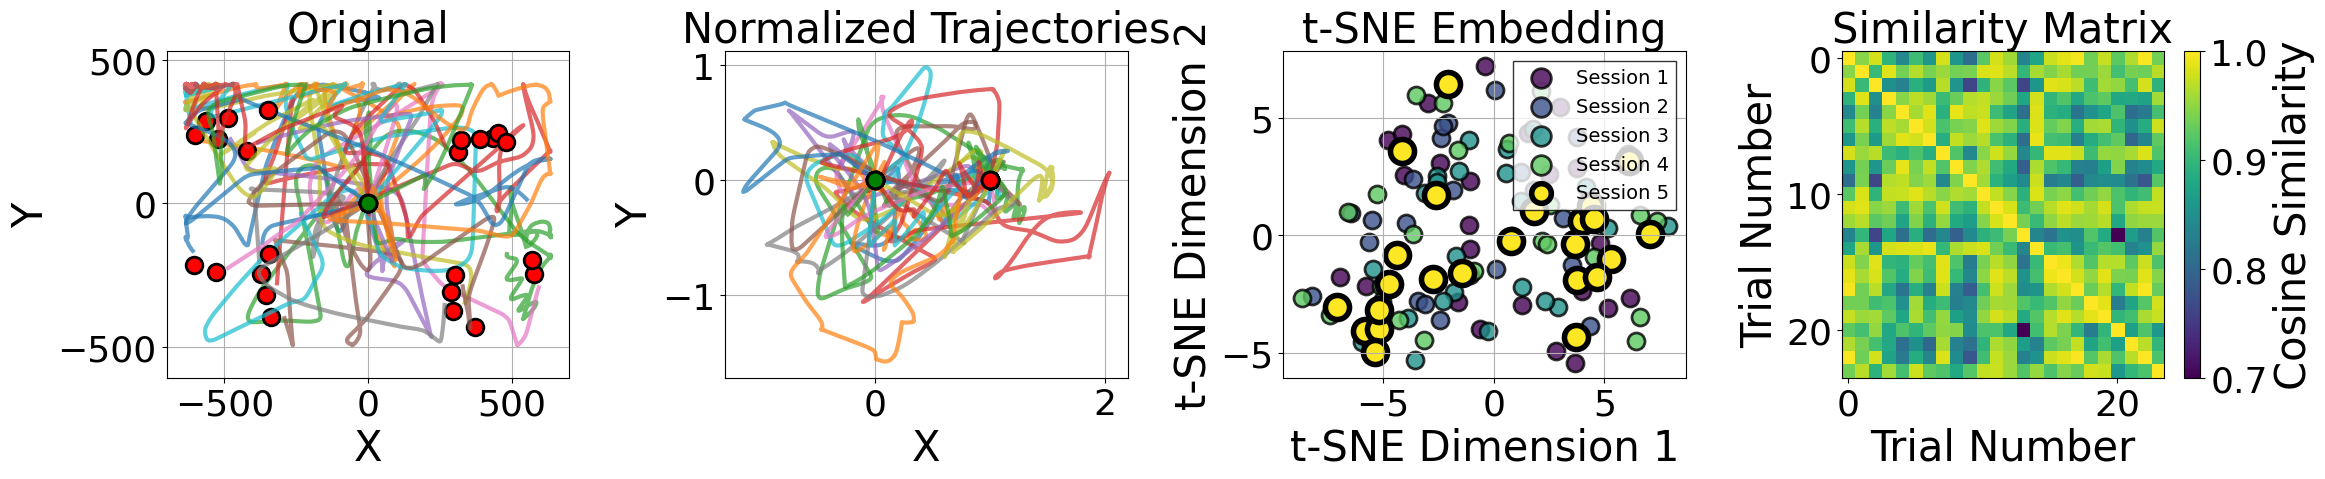

Participant MTRLRN030
Number of trials: 24
Success rate: 70.83%
Average completion time: 7.55 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.9335
Mean Consistency Score: 0.9526
Overall Movement Consistency: 0.9225
Figure saved to: MTRLRN030_Day1_Unimanual.png


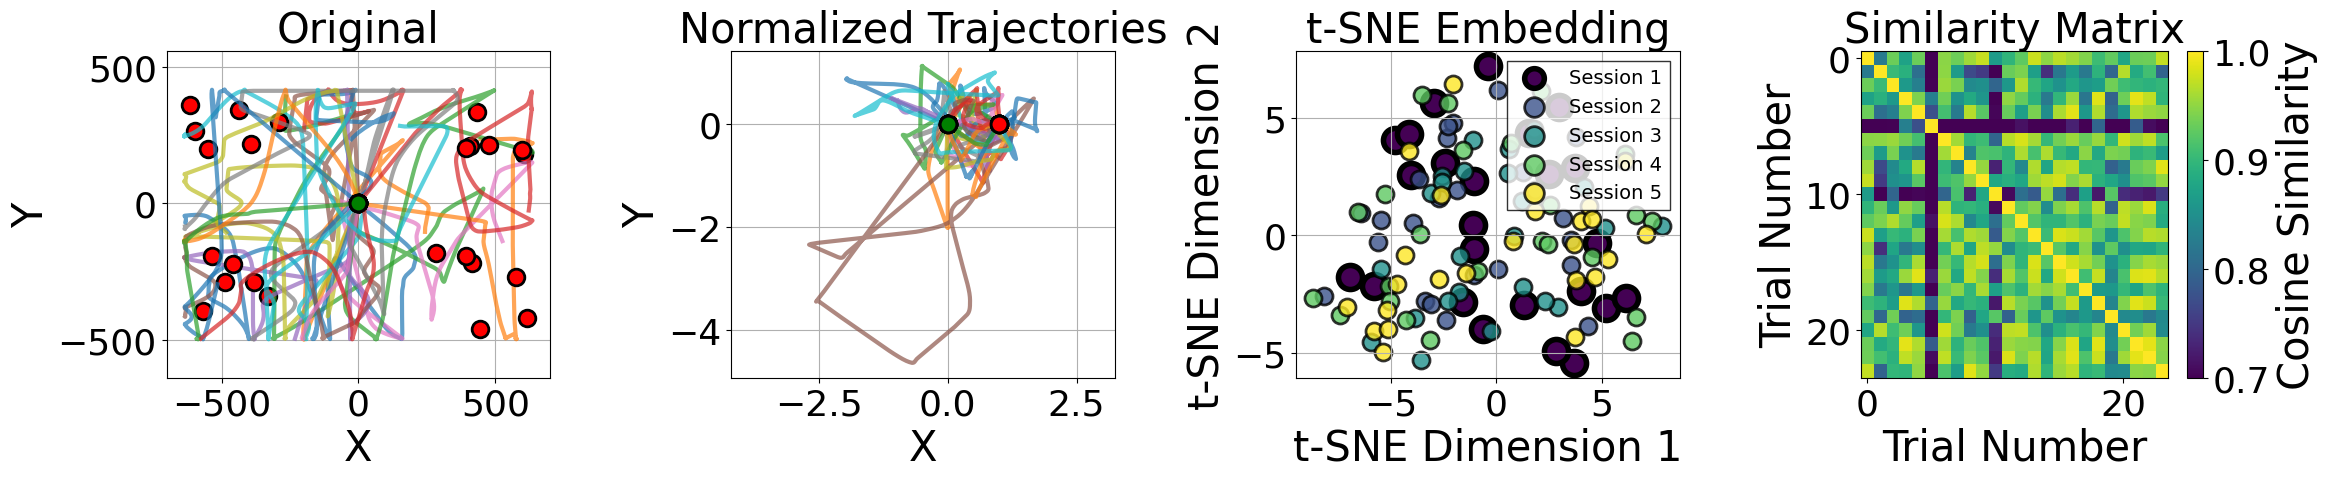

Participant MTRLRN030
Number of trials: 24
Success rate: 4.17%
Average completion time: 10.98 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.8823
Mean Consistency Score: 0.9202
Overall Movement Consistency: 0.8849


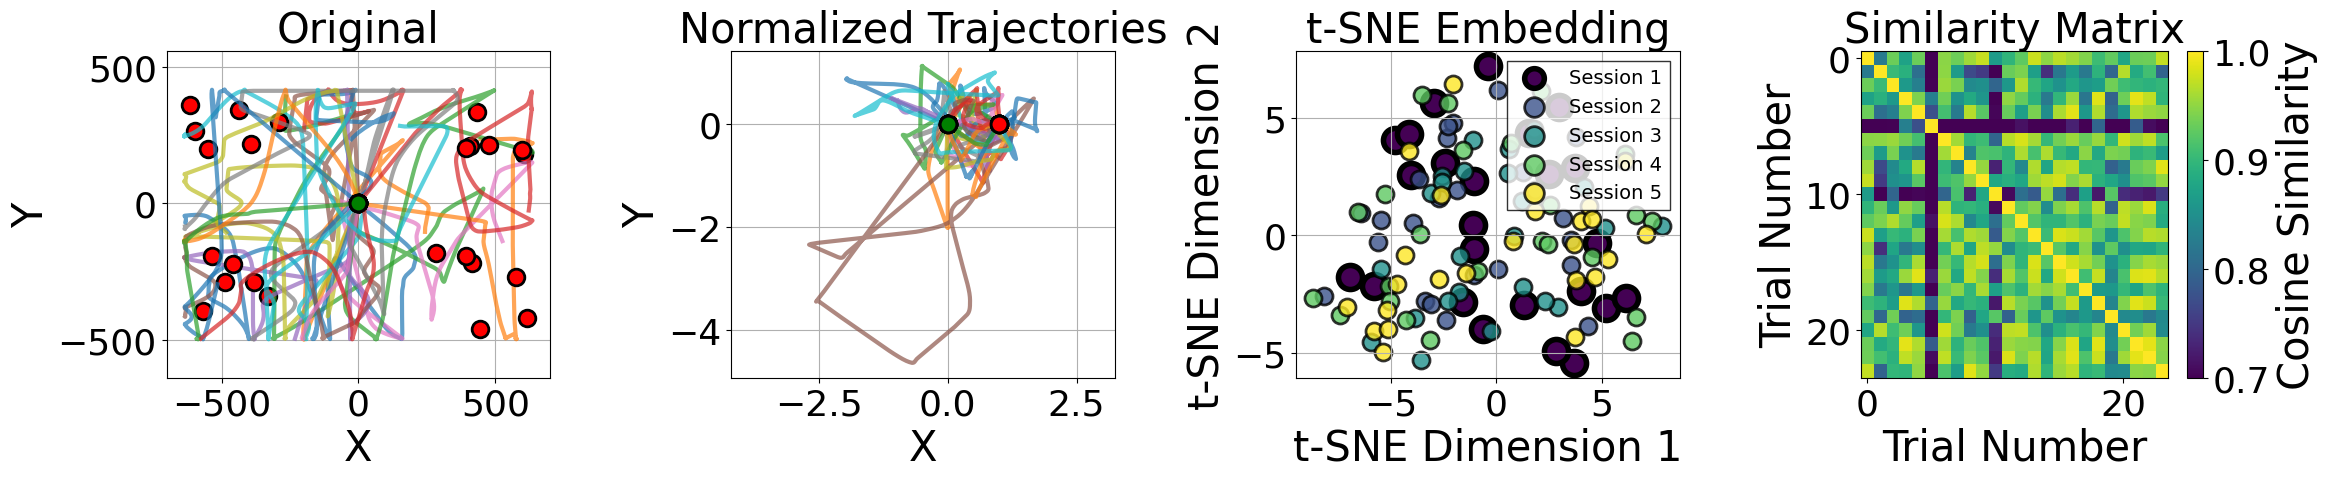

In [45]:
embedding_column = "trajectory_embedding_weighted_multi"
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN030", task_type="Unimanual", session_no=5, embedding_column=embedding_column, day=7, 
                                  save_path="MTRLRN030_Day7_Unimanual.png")
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN030", task_type="Unimanual", session_no=1, embedding_column=embedding_column, day=1, 
                                  save_path="MTRLRN030_Day1_Unimanual.png")


Figure saved to: MTRLRN070_Day7_Unimanual.png


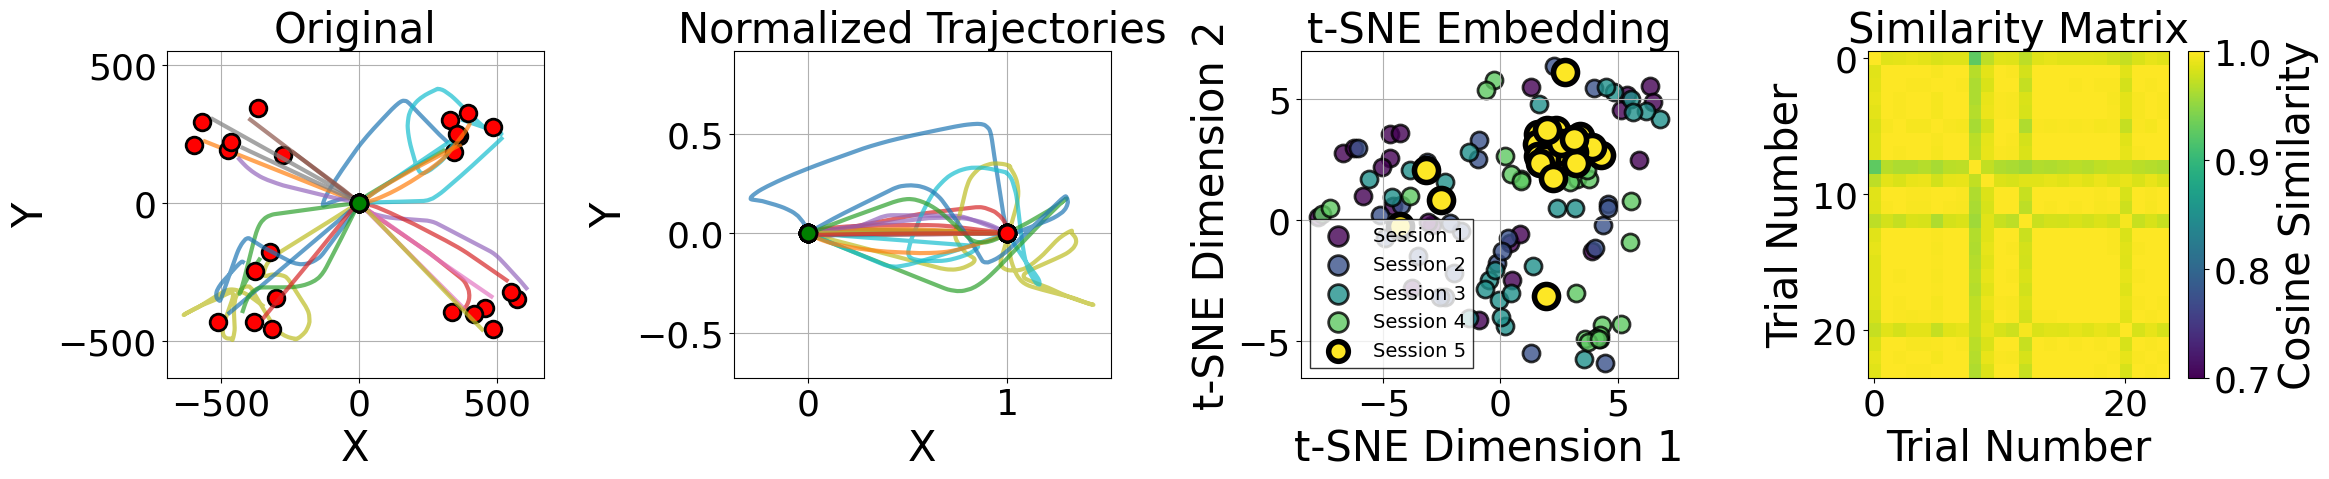

Participant MTRLRN070
Number of trials: 24
Success rate: 100.00%
Average completion time: 2.36 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.9918
Mean Consistency Score: 0.9951
Overall Movement Consistency: 0.9920
Figure saved to: MTRLRN070_Day1_Unimanual.png


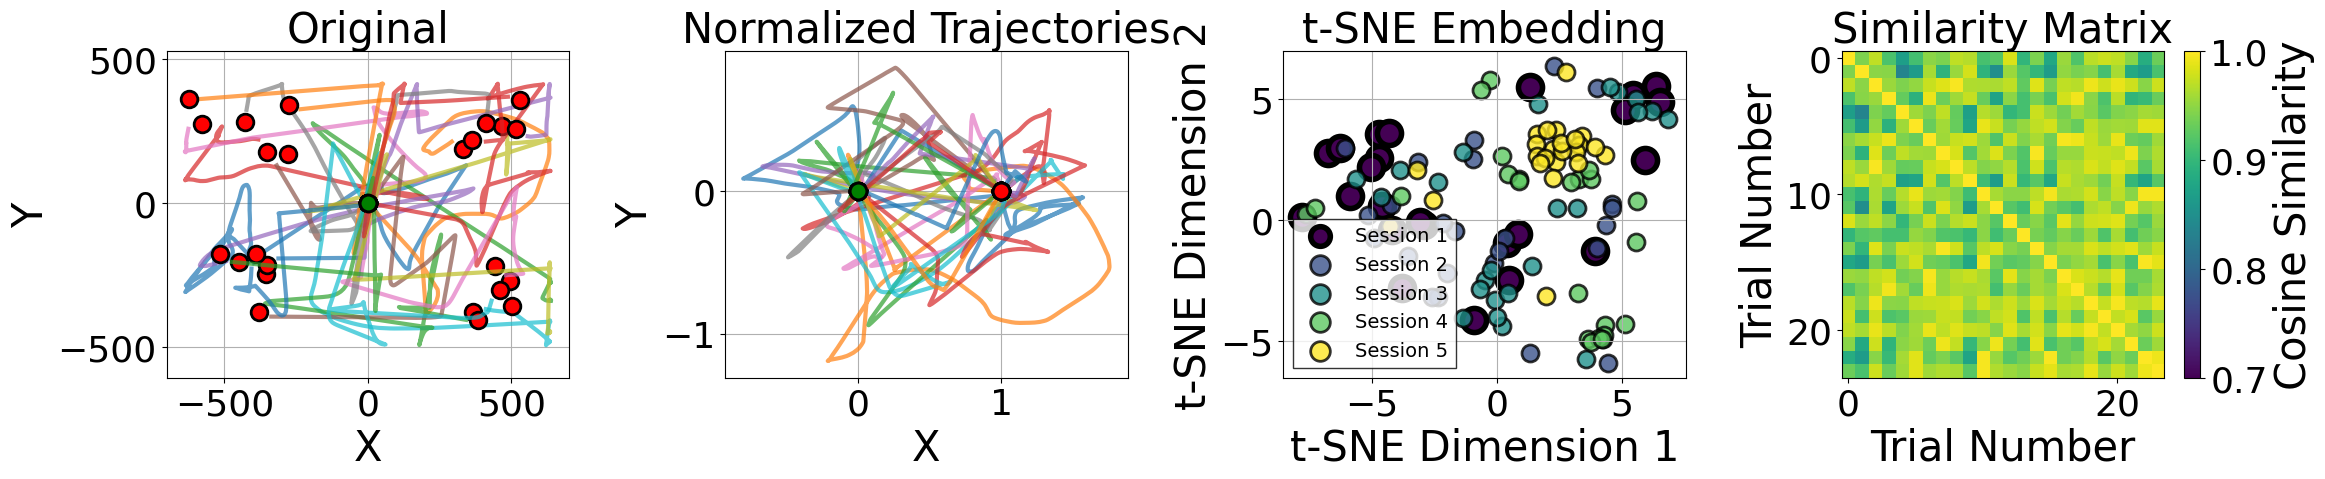

Participant MTRLRN070
Number of trials: 24
Success rate: 91.67%
Average completion time: 7.34 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.9522
Mean Consistency Score: 0.9689
Overall Movement Consistency: 0.9511


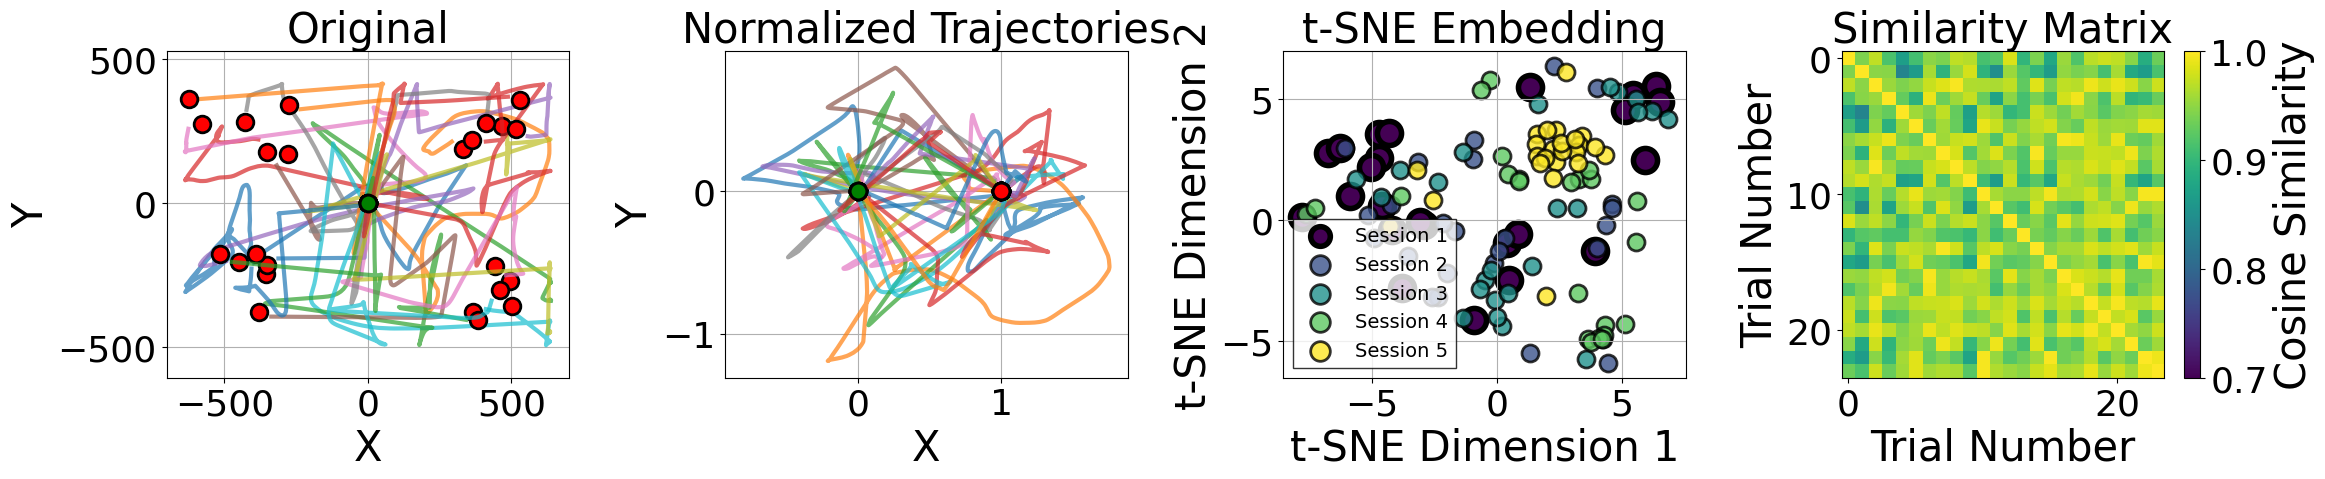

In [43]:
embedding_column = "trajectory_embedding_weighted_multi"
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN070", task_type="Unimanual", session_no=5, embedding_column=embedding_column, day=7, save_path="MTRLRN070_Day7_Unimanual.png")
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN070", task_type="Unimanual", session_no=1, embedding_column=embedding_column, day=1, save_path="MTRLRN070_Day1_Unimanual.png")


/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_23984/2250404559.py:140: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


Figure saved to: MTRLRN070_Day7_Unimanual.png


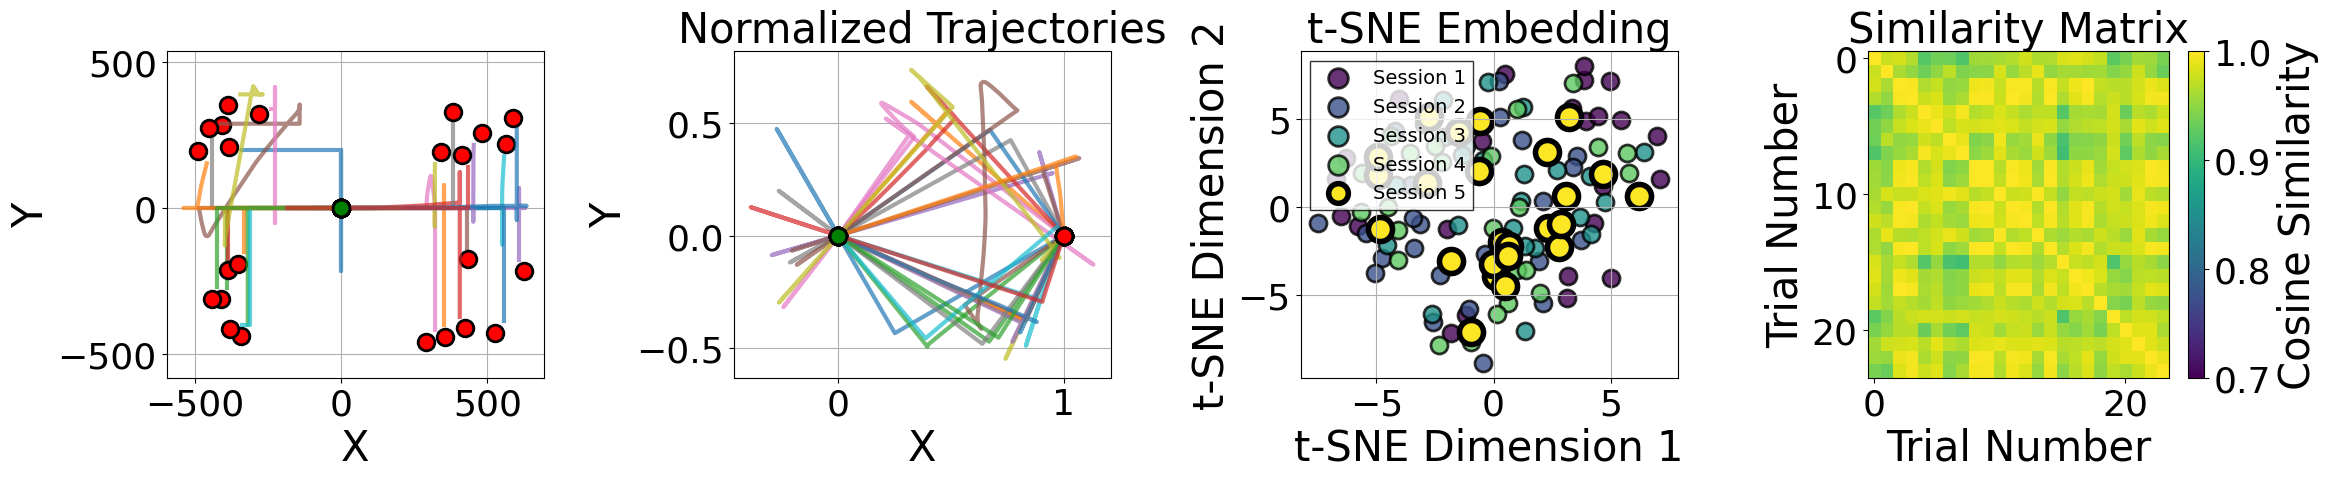

Participant MTRLRN015
Number of trials: 24
Success rate: 100.00%
Average completion time: 5.10 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.9772
Mean Consistency Score: 0.9828
Overall Movement Consistency: 0.9717


/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_23984/2250404559.py:140: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


Figure saved to: MTRLRN070_Day1_Unimanual.png


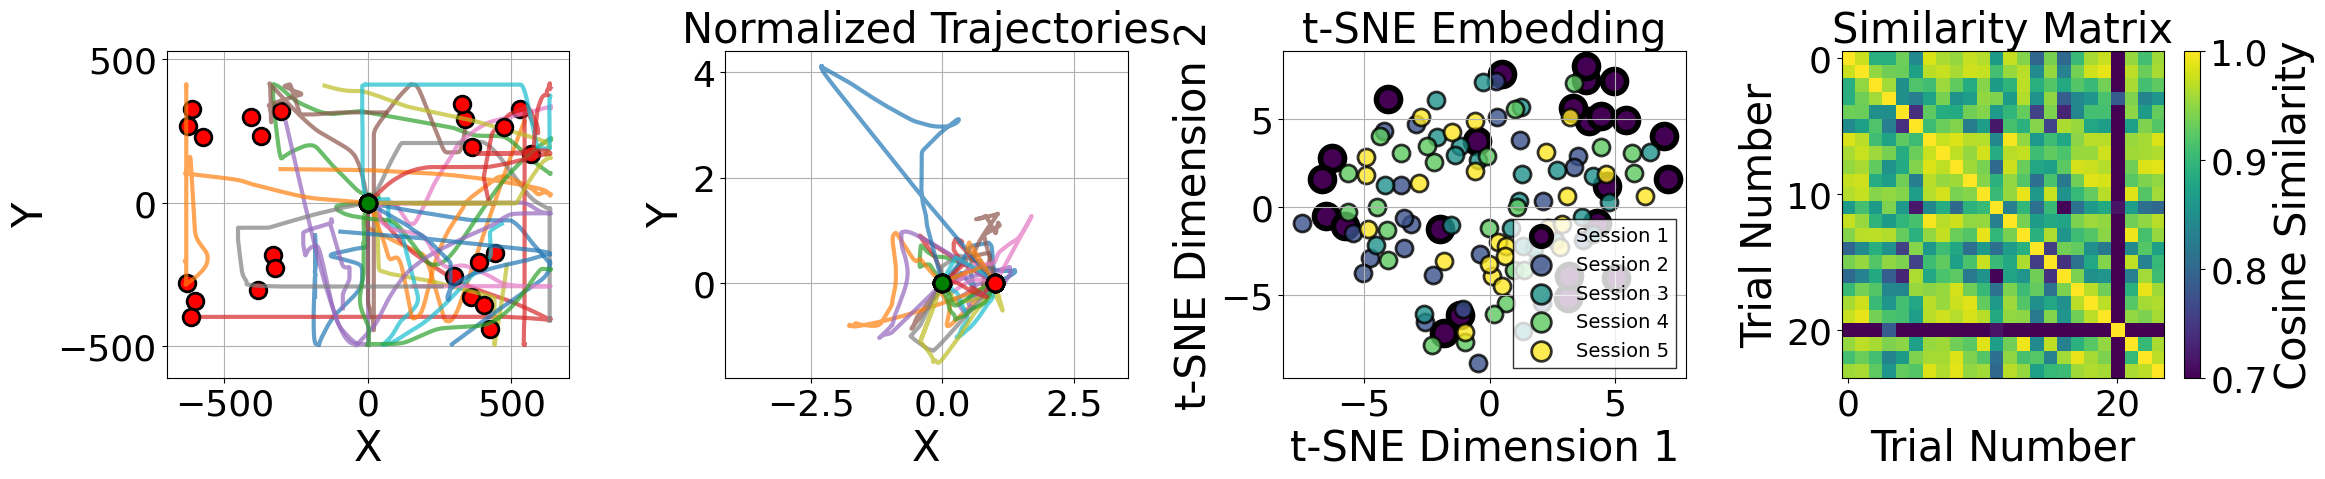

Participant MTRLRN015
Number of trials: 24
Success rate: 20.83%
Average completion time: 10.19 ms

Similarity Statistics:
Mean Trial-to-Trial Similarity: 0.8764
Mean Consistency Score: 0.9312
Overall Movement Consistency: 0.8857


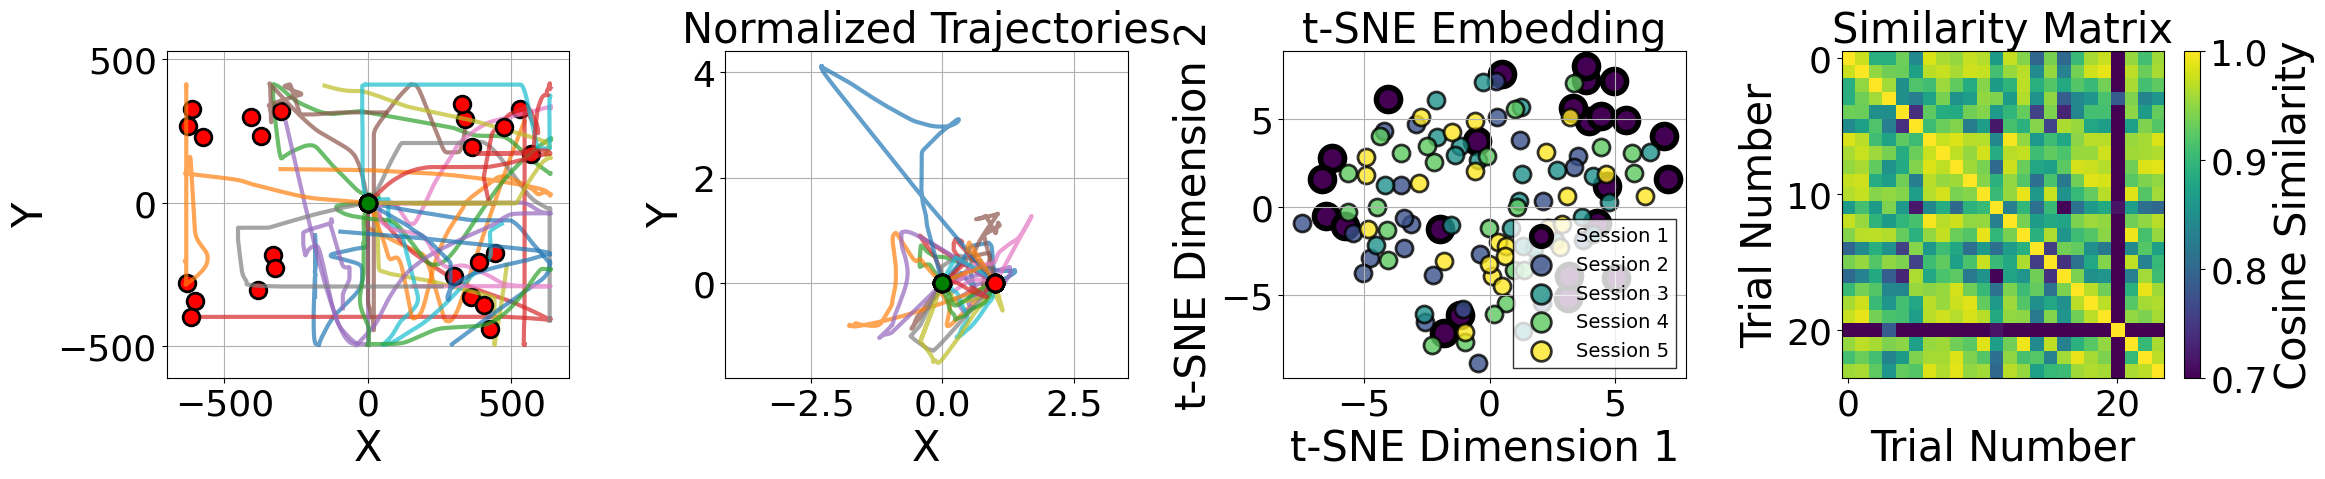

In [ ]:
embedding_column = "trajectory_embedding_weighted_multi"
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN015", task_type="Bimanual", session_no=5, embedding_column=embedding_column, day=7, save_path="MTRLRN070_Day7_Unimanual.png")
plot_trajectories_with_similarity(df_with_ratio_progress, participant_id="MTRLRN015", task_type="Bimanual", session_no=1, embedding_column=embedding_column, day=1, save_path="MTRLRN070_Day1_Unimanual.png")


In [ ]:
df_with_ratio_progress.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_sequential', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success', 'trajectory_embedding_multi',
       'trajectory_embedding_weighted_multi', 'exploration_score',
       'exploitation_score', 'novelty', 'avg_similarity_to_window',
       'max_similarity_to_window', 'trial_seq', 'task_label',
       'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')

## Hypothesis 3a: Movement performance variables such as movement speed or accuracy will correlate negatively or positively with E-E ratio and vice versa. 

In [ ]:
data_path = "../Dataset/SMT_dataset/preprocessed_human_smt_dataset.csv"
df_data = pd.read_csv(data_path)
df_data['participant_id'], unique_participants = pd.factorize(df_data['participant_id'])
df_data

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,time_diff_ms,Age,Cohort,Gestational_Age,mabc_total_test_score,mabc_standard_score,mabc_percentile,distances,rmsd,normalized_trajectory
0,0,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,"[16, 31, 45, 62, 76, 91, 106, 136, 137, 166, 1...",5,Preterm,33.0,79,10,50.0,[630.49169002 621.50505278 612.7228091 604.15...,110.541539,[[ 0.00000000e+00 0.00000000e+00 1.60000000e...
1,0,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,"[1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, ...",5,Preterm,33.0,79,10,50.0,[682.05597088 675.4999193 668.9795427 662.49...,304.594913,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...
2,0,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,"[0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...",5,Preterm,33.0,79,10,50.0,[645.53528595 645.53528595 645.53528595 645.53...,132.644564,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...
3,0,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, ...",5,Preterm,33.0,79,10,50.0,[ 517.11764079 510.62061574 504.23767571 49...,462.858263,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...
4,0,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,"[0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, ...",5,Preterm,33.0,79,10,50.0,[548.60482324 540.93551793 533.34320676 525.83...,364.397944,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,67,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,"[12, 21, 33, 41, 51, 65, 71, 83, 91, 101, 111,...",8,Term,40.0,35,2,0.5,[405.89604257 404.46647187 403.03736672 ... 30...,220.500581,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...
16316,67,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,"[12, 20, 33, 40, 51, 61, 70, 83, 91, 101, 111,...",8,Term,40.0,35,2,0.5,[582.47960403 585.99988001 589.52453666 592.88...,54.671025,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...
16317,67,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,"[37, 41, 51, 61, 71, 84, 91, 101, 111, 121, 13...",8,Term,40.0,35,2,0.5,[627.17523828 628.25034819 629.33028672 630.41...,151.594559,[[ 0.00000000e+00 0.00000000e+00 3.70000000e...
16318,67,5,1,23,Day-3,Block-1,0,0,559.127069,355.643316,...,"[28, 31, 42, 53, 62, 75, 81, 91, 103, 112, 121...",8,Term,40.0,35,2,0.5,[ 664.12568906 665.60456108 667.08677801 66...,362.868256,[[ 0.00000000e+00 0.00000000e+00 2.80000000e...


In [ ]:
df_ratio = df_with_ratio_progress[['participant_id', 'exploration_score', 'exploitation_score', 'exploration_exploitation_ratio']]
df_ratio.columns

Index(['participant_id', 'exploration_score', 'exploitation_score',
       'exploration_exploitation_ratio'],
      dtype='object')

In [ ]:
df_ratio_merged = pd.merge(df_data, df_ratio, left_index=True, right_index=True)
df_ratio_merged

,participant_id_x,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,mabc_total_test_score,mabc_standard_score,mabc_percentile,distances,rmsd,normalized_trajectory,participant_id_y,exploration_score,exploitation_score,exploration_exploitation_ratio
0,0,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,79,10,50.0,[630.49169002 621.50505278 612.7228091 604.15...,110.541539,[[ 0.00000000e+00 0.00000000e+00 1.60000000e...,0,0.048183,0.000000,4.818315
1,0,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,79,10,50.0,[682.05597088 675.4999193 668.9795427 662.49...,304.594913,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...,0,0.233841,0.170576,1.294971
2,0,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,79,10,50.0,[645.53528595 645.53528595 645.53528595 645.53...,132.644564,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...,0,0.123192,0.280172,0.424550
3,0,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,79,10,50.0,[ 517.11764079 510.62061574 504.23767571 49...,462.858263,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...,0,0.100758,0.321796,0.303676
4,0,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,79,10,50.0,[548.60482324 540.93551793 533.34320676 525.83...,364.397944,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...,0,0.091640,0.342180,0.260208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,67,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,35,2,0.5,[405.89604257 404.46647187 403.03736672 ... 30...,220.500581,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...,67,0.014563,0.491053,0.029065
16316,67,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,35,2,0.5,[582.47960403 585.99988001 589.52453666 592.88...,54.671025,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...,67,0.013197,0.201343,0.062444
16317,67,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,35,2,0.5,[627.17523828 628.25034819 629.33028672 630.41...,151.594559,[[ 0.00000000e+00 0.00000000e+00 3.70000000e...,67,0.023016,0.413976,0.054287
16318,67,5,1,23,Day-3,Block-1,0,0,559.127069,355.643316,...,35,2,0.5,[ 664.12568906 665.60456108 667.08677801 66...,362.868256,[[ 0.00000000e+00 0.00000000e+00 2.80000000e...,67,0.051534,0.360152,0.139224


In [ ]:
df_ratio_merged.columns

Index(['participant_id_x', 'session_no', 'task_type', 'trial_no', 'day',
       'block', 'start_point_x', 'start_point_y', 'target_point_x',
       'target_point_y', 'start_time', 'end_time', 'quadrant', 'is_success',
       'actual_dist', 'movement_dist', 'completion_time', 'path',
       'time_string', 'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory', 'participant_id_y',
       'exploration_score', 'exploitation_score',
       'exploration_exploitation_ratio'],
      dtype='object')

In [ ]:
df_ratio_merged_ = df_ratio_merged[['Cohort','actual_dist', 'movement_dist', 'completion_time', 'rmsd', 'exploration_score', 'exploitation_score',
       'exploration_exploitation_ratio']]

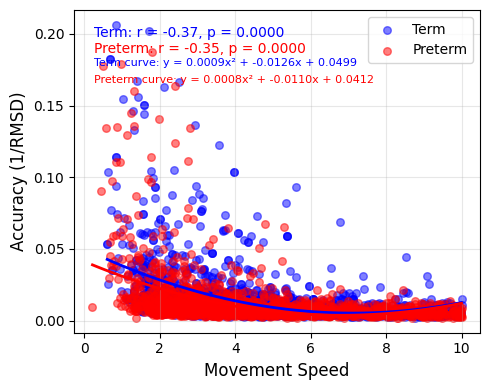

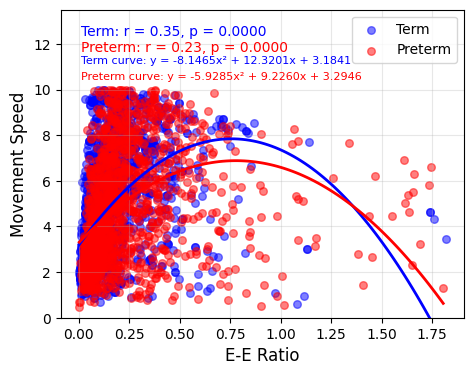

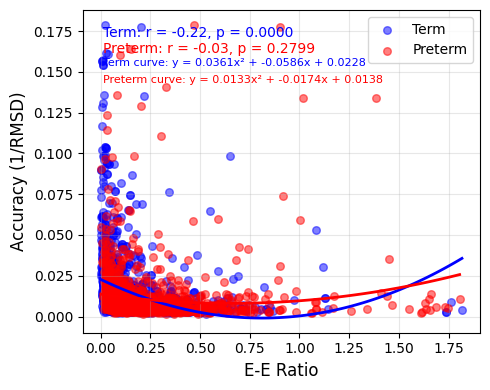

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.utils import resample

def analyze_speed_accuracy_tradeoff(df):
    """
    Create a plot analyzing speed-accuracy trade-offs between Term and Preterm groups,
    using sampling to balance the groups. Removes samples with speed <= 10.
    Fits polynomial curves instead of linear regression lines.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance data and Cohort information
    
    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    # Remove outliers
    df = df[df['completion_time'] <= 10]
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics
    df['movement_speed'] = df['completion_time']  # As provided in code
    df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'Cohort'])
    
   
    
    # Remove outliers (values beyond 3 standard deviations from the mean)
    for metric in ['movement_speed', 'accuracy']:
        mean = df[metric].mean()
        std = df[metric].std()
        df = df[(df[metric] >= mean - 3*std) & (df[metric] <= mean + 3*std)]
    
    # Split data by cohort
    term_data = df[df['Cohort'] == 'Term']
    preterm_data = df[df['Cohort'] == 'Preterm']
    
    # Apply sampling to balance the groups
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data = resample(term_data, n_samples=min_samples, random_state=42)
    if len(preterm_data) > min_samples:
        preterm_data = resample(preterm_data, n_samples=min_samples, random_state=42)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Scatter plot for each group
    ax.scatter(term_data['movement_speed'], term_data['accuracy'], 
               color='blue', alpha=0.5, s=30, label='Term')
    ax.scatter(preterm_data['movement_speed'], preterm_data['accuracy'], 
               color='red', alpha=0.5, s=30, label='Preterm')
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        # Sort x values for smooth curve
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        # Fit polynomial degree 2 (quadratic)
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        # Create points for smooth curve
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        # Plot the curve
        ax.plot(x_curve, y_curve, color=color, linewidth=2)
        
        return coeffs
    
    # Fit polynomial curves for each group
    term_coeffs = fit_and_plot_poly_curve(term_data['movement_speed'], term_data['accuracy'], 'blue', ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data['movement_speed'], preterm_data['accuracy'], 'red', ax)
    
    # Calculate and add correlation statistics for each group
    r_term, p_term = stats.pearsonr(term_data['movement_speed'], term_data['accuracy'])
    r_preterm, p_preterm = stats.pearsonr(preterm_data['movement_speed'], preterm_data['accuracy'])
    
    # Add statistics to plot
    ax.text(0.05, 0.95, f'Term: r = {r_term:.2f}, p = {p_term:.4f}', 
            transform=ax.transAxes, fontsize=10, va='top', color='blue')
    ax.text(0.05, 0.90, f'Preterm: r = {r_preterm:.2f}, p = {p_preterm:.4f}', 
            transform=ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    ax.text(0.05, 0.85, f'Term curve: {term_eq}', 
            transform=ax.transAxes, fontsize=8, va='top', color='blue')
    ax.text(0.05, 0.80, f'Preterm curve: {preterm_eq}', 
            transform=ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    ax.set_xlabel('Movement Speed', fontsize=12)
    ax.set_ylabel('Accuracy (1/RMSD)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    
    return fig


def analyze_ratio_vs_performance(df):
    """
    Create two plots analyzing:
    1. Speed vs exploration_exploitation_ratio for Term and Preterm
    2. Accuracy vs exploration_exploitation_ratio for Term and Preterm
    Removes samples with speed <= 10 and fits polynomial curves.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with performance, exploration/exploitation data, and Cohort information
    
    Returns:
    --------
    tuple
        (speed_figure, accuracy_figure)
    """
    # Make a copy of the dataframe and ensure all needed columns are numeric
    df = df.copy()
    df = df[~((df['session_no'] == 1) & (df['trial_no'].isin([1, 2, 3])))]
    df = df[df['completion_time'] <= 10]
    
    # Ensure numerical data types for relevant columns
    numeric_cols = ['movement_dist', 'completion_time', 'rmsd', 
                   'exploration_score', 'exploitation_score', 'exploration_exploitation_ratio']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate performance metrics if they don't exist
    if 'movement_speed' not in df.columns:
        df['movement_speed'] = df['completion_time']  # As provided in code
    if 'accuracy' not in df.columns:
        df['accuracy'] = 1/df['rmsd']
    
    # Replace infinites with NaN and drop NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['movement_speed', 'accuracy', 'exploration_exploitation_ratio', 'Cohort'])
    
    # Remove samples with speed > 10
    
    
    # Remove outliers (values beyond 3 standard deviations from the mean)
    for metric in ['movement_speed', 'accuracy', 'exploration_exploitation_ratio']:
        mean = df[metric].mean()
        std = df[metric].std()
        df = df[(df[metric] >= mean - 3*std) & (df[metric] <= mean + 3*std)]
    
    # Split data by cohort
    term_data = df[df['Cohort'] == 'Term']
    preterm_data = df[df['Cohort'] == 'Preterm']
    
    # Apply sampling to balance the groups if needed
    min_samples = min(len(term_data), len(preterm_data))
    
    if len(term_data) > min_samples:
        term_data_sampled = resample(term_data, n_samples=min_samples, random_state=42)
    else:
        term_data_sampled = term_data.copy()
        
    if len(preterm_data) > min_samples:
        preterm_data_sampled = resample(preterm_data, n_samples=min_samples, random_state=42)
    else:
        preterm_data_sampled = preterm_data.copy()
    
    # Function to fit and plot polynomial curve
    def fit_and_plot_poly_curve(x, y, color, ax):
        # Sort x values for smooth curve
        idx = np.argsort(x)
        x_sorted = np.array(x.iloc[idx])
        y_sorted = np.array(y.iloc[idx])
        
        # Fit polynomial degree 2 (quadratic)
        coeffs = np.polyfit(x_sorted, y_sorted, 2)
        
        # Create points for smooth curve
        x_curve = np.linspace(min(x_sorted), max(x_sorted), 100)
        y_curve = np.polyval(coeffs, x_curve)
        
        # Plot the curve
        ax.plot(x_curve, y_curve, color=color, linewidth=2)
        
        return coeffs
    
    # 1. Create figure for Speed vs E-E Ratio
    speed_fig, speed_ax = plt.subplots(figsize=(5.2, 4))
    
    # Scatter plot for each group
    speed_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['movement_speed'], 
                     color='blue', alpha=0.5, s=30, label='Term')
    speed_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['movement_speed'], 
                     color='red', alpha=0.5, s=30, label='Preterm')
    
    # Fit polynomial curves for each group
    term_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                         term_data_sampled['movement_speed'], 'blue', speed_ax)
    preterm_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                            preterm_data_sampled['movement_speed'], 'red', speed_ax)
    
    # Calculate correlation statistics
    r_term_speed, p_term_speed = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                                term_data_sampled['movement_speed'])
    r_preterm_speed, p_preterm_speed = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                     preterm_data_sampled['movement_speed'])
    
    # Add statistics to plot
    speed_ax.text(0.05, 0.95, f'Term: r = {r_term_speed:.2f}, p = {p_term_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=10, va='top', color='blue')
    speed_ax.text(0.05, 0.90, f'Preterm: r = {r_preterm_speed:.2f}, p = {p_preterm_speed:.4f}', 
                  transform=speed_ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_eq = f"y = {term_coeffs[0]:.4f}x² + {term_coeffs[1]:.4f}x + {term_coeffs[2]:.4f}"
    preterm_eq = f"y = {preterm_coeffs[0]:.4f}x² + {preterm_coeffs[1]:.4f}x + {preterm_coeffs[2]:.4f}"
    
    speed_ax.text(0.05, 0.85, f'Term curve: {term_eq}', 
                  transform=speed_ax.transAxes, fontsize=8, va='top', color='blue')
    speed_ax.text(0.05, 0.80, f'Preterm curve: {preterm_eq}', 
                  transform=speed_ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    speed_ax.set_xlabel('E-E Ratio', fontsize=12)
    speed_ax.set_ylabel('Movement Speed', fontsize=12)
    speed_ax.grid(True, alpha=0.3)
    speed_ax.legend()
    speed_ax.set_ylim(0,13.5)
    
    # 2. Create figure for Accuracy vs E-E Ratio
    acc_fig, acc_ax = plt.subplots(figsize=(5, 4))
    
    # Scatter plot for each group
    acc_ax.scatter(term_data_sampled['exploration_exploitation_ratio'], term_data_sampled['accuracy'], 
                   color='blue', alpha=0.5, s=30, label='Term')
    acc_ax.scatter(preterm_data_sampled['exploration_exploitation_ratio'], preterm_data_sampled['accuracy'], 
                   color='red', alpha=0.5, s=30, label='Preterm')
    
    # Fit polynomial curves for each group
    term_acc_coeffs = fit_and_plot_poly_curve(term_data_sampled['exploration_exploitation_ratio'], 
                                            term_data_sampled['accuracy'], 'blue', acc_ax)
    preterm_acc_coeffs = fit_and_plot_poly_curve(preterm_data_sampled['exploration_exploitation_ratio'], 
                                               preterm_data_sampled['accuracy'], 'red', acc_ax)
    
    # Calculate correlation statistics
    r_term_acc, p_term_acc = stats.pearsonr(term_data_sampled['exploration_exploitation_ratio'], 
                                           term_data_sampled['accuracy'])
    r_preterm_acc, p_preterm_acc = stats.pearsonr(preterm_data_sampled['exploration_exploitation_ratio'], 
                                                 preterm_data_sampled['accuracy'])
    
    # Add statistics to plot
    acc_ax.text(0.05, 0.95, f'Term: r = {r_term_acc:.2f}, p = {p_term_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=10, va='top', color='blue')
    acc_ax.text(0.05, 0.90, f'Preterm: r = {r_preterm_acc:.2f}, p = {p_preterm_acc:.4f}', 
                transform=acc_ax.transAxes, fontsize=10, va='top', color='red')
    
    # Add polynomial equations
    term_acc_eq = f"y = {term_acc_coeffs[0]:.4f}x² + {term_acc_coeffs[1]:.4f}x + {term_acc_coeffs[2]:.4f}"
    preterm_acc_eq = f"y = {preterm_acc_coeffs[0]:.4f}x² + {preterm_acc_coeffs[1]:.4f}x + {preterm_acc_coeffs[2]:.4f}"
    
    acc_ax.text(0.05, 0.85, f'Term curve: {term_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=8, va='top', color='blue')
    acc_ax.text(0.05, 0.80, f'Preterm curve: {preterm_acc_eq}', 
                transform=acc_ax.transAxes, fontsize=8, va='top', color='red')
    
    # Add labels
    acc_ax.set_xlabel('E-E Ratio', fontsize=12)
    acc_ax.set_ylabel('Accuracy (1/RMSD)', fontsize=12)
    acc_ax.grid(True, alpha=0.3)
    acc_ax.legend()
    
    plt.tight_layout()
    
    return (speed_fig, acc_fig)


# Example usage:
tradeoff_fig = analyze_speed_accuracy_tradeoff(df_ratio_merged)
speed_fig, acc_fig = analyze_ratio_vs_performance(df_ratio_merged)
plt.show()

### Predict optimal trails to prevent motor delay

Analyzing Preterm cohort, Bimanual task...
Analyzing Preterm cohort, Unimanual task...
Analyzing Term cohort, Bimanual task...
Analyzing Term cohort, Unimanual task...

--- KEY FINDINGS ---
Optimal Intervention Trial Numbers:
  Preterm - Bimanual: Trial 23
  Preterm - Unimanual: Trial 60
  Term - Bimanual: Trial 18
  Term - Unimanual: Trial 18

Transition Points (Exploration to Exploitation):
  Preterm - Bimanual: Trial 17
  Preterm - Unimanual: Trial 54
  Term - Bimanual: Trial 17
  Term - Unimanual: Trial 17

Stabilization Points (95% CI method):
  Preterm - Bimanual: Trial 107
  Preterm - Unimanual: Trial 62
  Term - Bimanual: Trial 107
  Term - Unimanual: Trial 83

Learning Rates (E-E Ratio Slope):
  Preterm - Bimanual: -0.005216
  Preterm - Unimanual: -0.004555
  Term - Bimanual: -0.004730
  Term - Unimanual: -0.004932

Differences in Optimal Trials (Preterm - Term):
  Unimanual: 42 additional trials
  Bimanual: 5 additional trials


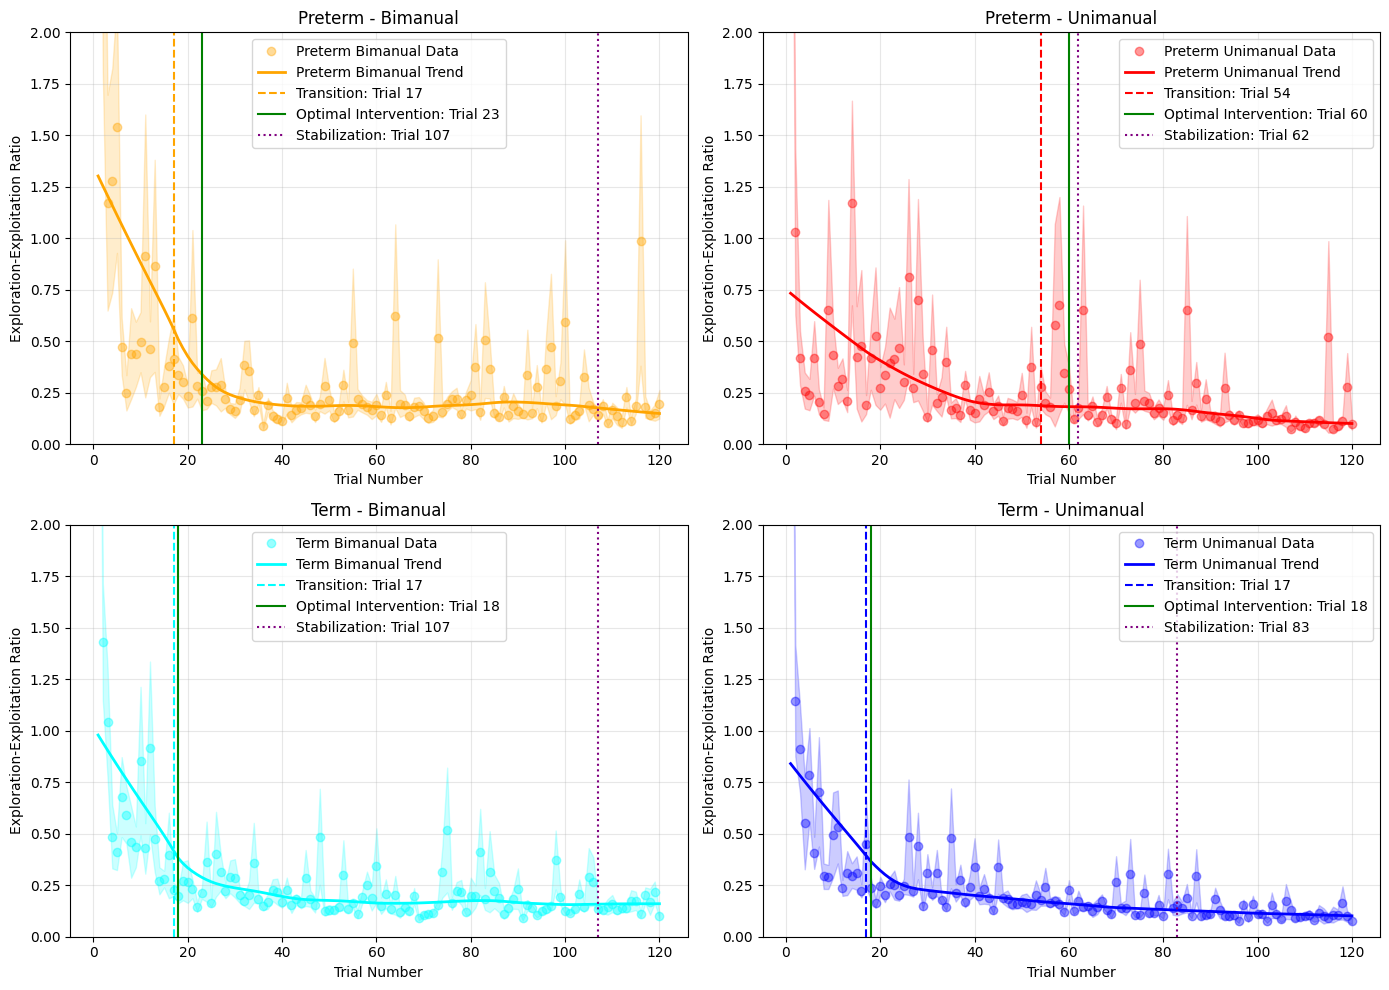

<Figure size 1000x600 with 0 Axes>

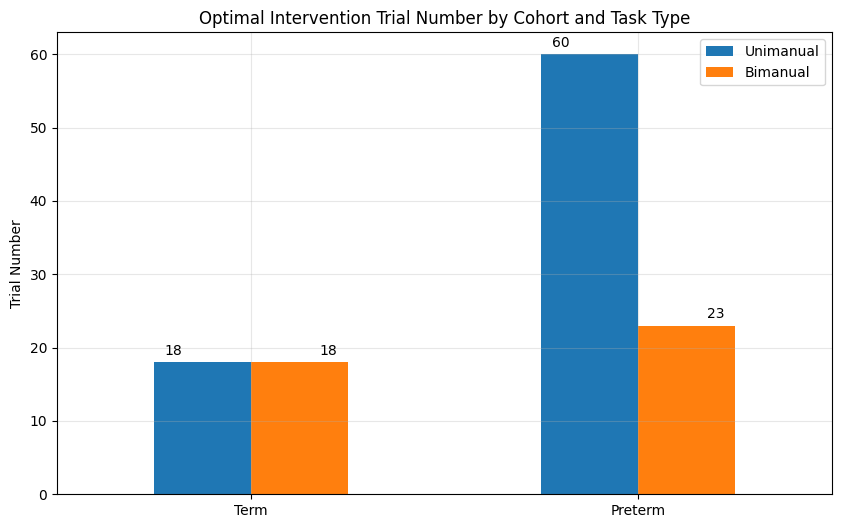

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

def predict_optimal_intervention_trials(df):
    """
    Analyze E-E ratio patterns to predict optimal trial numbers for intervention
    to prevent motor delays in term and preterm children.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: participant_id, session_no, trial_no, Cohort, 
        task_type, and exploration_exploitation_ratio
    
    Returns:
    --------
    dict
        Dictionary containing optimal trial recommendations and analysis results
    """
    # Ensure the column name is correct
    if 'exploration_exploitation_ration' in df.columns:
        df = df.rename(columns={'exploration_exploitation_ration': 'exploration_exploitation_ratio'})
        
    # Create task type labels for better readability
    df['task_name'] = df['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    # Ensure data types
    df['session_no'] = df['session_no'].astype(int)
    df['trial_no'] = df['trial_no'].astype(int)
    
    # Create a normalized trial number across sessions for continuity analysis
    df['global_trial'] = (df['session_no'] - 1) * 24 + df['trial_no']
    
    # Create groups for analysis
    groups = df.groupby(['Cohort', 'task_name'])
    
    # Results storage
    results = {
        'optimal_trials': {},
        'transition_points': {},
        'learning_rates': {},
        'stabilization_points': {},
        'plots': {}
    }
    
    # Color mapping for consistent visualization
    colors = {
        ('Term', 'Unimanual'): 'blue',
        ('Term', 'Bimanual'): 'cyan',
        ('Preterm', 'Unimanual'): 'red',
        ('Preterm', 'Bimanual'): 'orange'
    }
    
    # Create main figure for trajectory analysis
    plt.figure(figsize=(14, 10))
    
    # Analyze each cohort and task type
    for (cohort, task), group_data in groups:
        print(f"Analyzing {cohort} cohort, {task} task...")
        
        # Aggregate data across participants to get mean E-E ratio per trial
        trial_means = group_data.groupby('global_trial')['exploration_exploitation_ratio'].agg(
            ['mean', 'std', 'count']).reset_index()
        trial_means['sem'] = trial_means['std'] / np.sqrt(trial_means['count'])
        
        # Fit linear regression to detect overall trend
        X = trial_means['global_trial'].values.reshape(-1, 1)
        y = trial_means['mean'].values
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]
        
        # Smooth the data for better trend analysis
        smoothed = lowess(trial_means['mean'], trial_means['global_trial'], frac=0.3)
        
        # Find transition points (where rate of change in E-E ratio shifts significantly)
        # Calculate first derivative of smoothed curve
        derivative = np.gradient(smoothed[:, 1])
        
        # Find peaks in the negative of first derivative (points where decrease is sharpest)
        peaks, _ = find_peaks(-derivative, height=0.0001, distance=10)
        
        if len(peaks) > 0:
            # First significant decrease in E-E ratio
            transition_point = smoothed[peaks[0], 0]
        else:
            # If no clear transition point, estimate based on when E-E ratio drops below threshold
            # Define different thresholds for Term vs Preterm
            threshold = 0.10 if cohort == 'Term' else 0.15
            below_threshold = np.where(smoothed[:, 1] < threshold)[0]
            transition_point = smoothed[below_threshold[0], 0] if len(below_threshold) > 0 else len(smoothed)
        
        # Find stabilization point (where E-E ratio flattens)
        # Use 95% CI of sequential differences in smoothed data instead of standard deviation
        diffs = np.diff(smoothed[:, 1])
        window_size = 24
        
        # Calculate 95% CI width for each sliding window
        ci_widths = []
        for i in range(len(diffs) - window_size):
            window_diffs = diffs[i:i+window_size]
            std_error = np.std(window_diffs) / np.sqrt(window_size)
            ci_width = 1.96 * 2 * std_error  # 95% CI width = 2 * 1.96 * SE
            ci_widths.append(ci_width)
        
        # Find where CI width is minimized (indicates stabilization)
        if len(ci_widths) > 0:
            stabilization_idx = np.argmin(ci_widths) + window_size//2
            stabilization_point = smoothed[stabilization_idx, 0] if stabilization_idx < len(smoothed) else len(smoothed)
        else:
            stabilization_point = len(smoothed)
        
        # Determine optimal intervention point based on cohort and task
        if cohort == 'Term':
            # For term children, intervene after the transition point plus small buffer
            optimal_trial = int(transition_point + 1)
        else:
            # For preterm children, either at transition point or after set number of trials
            # if no transition is observed
            has_transition = len(peaks) > 0
            if has_transition:
                optimal_trial = int(transition_point + 6)
            else:
                # If no clear transition, recommend intervention earlier
                optimal_trial = min(30, int(stabilization_point))
        
        # Store results
        key = (cohort, task)
        results['optimal_trials'][key] = optimal_trial
        results['transition_points'][key] = int(transition_point)
        results['learning_rates'][key] = slope
        results['stabilization_points'][key] = int(stabilization_point)
        
        # Plot the data
        plt.subplot(2, 2, len(results['optimal_trials']))
        
        # Plot raw means with error bands
        plt.plot(trial_means['global_trial'], trial_means['mean'], 'o', 
                 color=colors[key], alpha=0.4, label=f'{cohort} {task} Data')
        
        # Plot smoothed curve
        plt.plot(smoothed[:, 0], smoothed[:, 1], '-', 
                 color=colors[key], linewidth=2, label=f'{cohort} {task} Trend')
        
        # Fill between error bands
        plt.fill_between(
            trial_means['global_trial'],
            trial_means['mean'] - trial_means['sem'],
            trial_means['mean'] + trial_means['sem'],
            color=colors[key], alpha=0.2
        )
        
        # Mark transition point
        plt.axvline(x=transition_point, color=colors[key], linestyle='--', 
                    label=f'Transition: Trial {int(transition_point)}')
        
        # Mark optimal intervention point
        plt.axvline(x=optimal_trial, color='green', linestyle='-', 
                    label=f'Optimal Intervention: Trial {optimal_trial}')
        
        # Mark stabilization point
        plt.axvline(x=stabilization_point, color='purple', linestyle=':', 
                    label=f'Stabilization: Trial {int(stabilization_point)}')
        
        plt.title(f'{cohort} - {task}')
        plt.xlabel('Trial Number')
        plt.ylabel('Exploration-Exploitation Ratio')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.ylim(0,2)
    
    plt.tight_layout()
    results['plots']['trajectories'] = plt
    
    # Create comparative visualization for optimal trial recommendations
    plt.figure(figsize=(10, 6))
    
    # Organize data for bar plot
    cohorts = ['Term', 'Preterm']
    tasks = ['Unimanual', 'Bimanual']
    
    bar_data = pd.DataFrame(index=cohorts, columns=tasks)
    for cohort in cohorts:
        for task in tasks:
            bar_data.loc[cohort, task] = results['optimal_trials'].get((cohort, task), np.nan)
    
    # Create grouped bar chart
    bar_data.plot(kind='bar', figsize=(10, 6))
    plt.title('Optimal Intervention Trial Number by Cohort and Task Type')
    plt.ylabel('Trial Number')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    
    for i, cohort in enumerate(cohorts):
        for j, task in enumerate(tasks):
            value = bar_data.loc[cohort, task]
            if not np.isnan(value):
                plt.text(i-0.2+j*0.4, value+1, f'{int(value)}', ha='center')
    
    results['plots']['comparison'] = plt
    
    # Generate summary of findings
    results['summary'] = {
        'term_vs_preterm_difference': {
            'Unimanual': results['optimal_trials'].get(('Preterm', 'Unimanual'), 0) - 
                         results['optimal_trials'].get(('Term', 'Unimanual'), 0),
            'Bimanual': results['optimal_trials'].get(('Preterm', 'Bimanual'), 0) - 
                        results['optimal_trials'].get(('Term', 'Bimanual'), 0)
        },
        'learning_rate_comparison': {
            'Term_Unimanual_vs_Bimanual': results['learning_rates'].get(('Term', 'Unimanual'), 0) / 
                                        results['learning_rates'].get(('Term', 'Bimanual'), 1),
            'Preterm_Unimanual_vs_Bimanual': results['learning_rates'].get(('Preterm', 'Unimanual'), 0) / 
                                           results['learning_rates'].get(('Preterm', 'Bimanual'), 1)
        }
    }
    
    # Print key findings
    print("\n--- KEY FINDINGS ---")
    print("Optimal Intervention Trial Numbers:")
    for (cohort, task), trial in results['optimal_trials'].items():
        print(f"  {cohort} - {task}: Trial {trial}")
    
    print("\nTransition Points (Exploration to Exploitation):")
    for (cohort, task), point in results['transition_points'].items():
        print(f"  {cohort} - {task}: Trial {point}")
    
    print("\nStabilization Points (95% CI method):")
    for (cohort, task), point in results['stabilization_points'].items():
        print(f"  {cohort} - {task}: Trial {point}")
    
    print("\nLearning Rates (E-E Ratio Slope):")
    for (cohort, task), rate in results['learning_rates'].items():
        print(f"  {cohort} - {task}: {rate:.6f}")
    
    print("\nDifferences in Optimal Trials (Preterm - Term):")
    for task, diff in results['summary']['term_vs_preterm_difference'].items():
        print(f"  {task}: {diff} additional trials")
    
    return results

# Example usage:
results = predict_optimal_intervention_trials(df_with_ratio_progress)
results['plots']['trajectories'].show()
results['plots']['comparison'].show()

# Example usage:
# results = predict_optimal_intervention_trials(df_with_ratio_progress)
# results['plots']['main_trajectories'].show()
# results['plots']['optimal_trials_by_age_group'].show()
# results['plots']['optimal_trials_heatmap'].show()

In [ ]:
df_with_ratio_progress.columns

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss', 'exploration_score',
       'exploitation_score', 'novelty', 'avg_similarity_to_window',
       'max_similarity_to_window', 'trial_seq', 'task_label',
       'exploration_exploitation_ratio', 'learning_rate', 'strategy_stability',
       'task_name', 'global_trial'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as st
import pingouin as pg

def analyze_ee_ratio_by_age_task_cohort(df):
    """
    Statistical analysis of exploration_exploitation_ratio between age groups (5-6 and 7-8),
    task types (Unimanual vs Bimanual), and cohorts (Term vs Preterm).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with specified columns
    
    Returns:
    --------
    dict
        Dictionary containing statistical results and figures
    """
    # Create a copy to avoid modifying the original dataframe
    df_copy = df.copy()
    
    # Create age group column
    df_copy['AgeGroup'] = df_copy['Age'].apply(lambda x: '5-6' if x in [5, 6] else '7-8')
    
    # Create task type labels
    df_copy['TaskType'] = df_copy['task_type'].map({0: 'Unimanual', 1: 'Bimanual'})
    
    # Ensure categorical variables are properly encoded
    df_copy['AgeGroup'] = df_copy['AgeGroup'].astype('category')
    df_copy['TaskType'] = df_copy['TaskType'].astype('category')
    df_copy['Cohort'] = df_copy['Cohort'].astype('category')
    
    # Prepare results container
    results = {}
    
    # 1. Calculate descriptive statistics with 95% CI
    group_stats = []
    for cohort in df_copy['Cohort'].unique():
        for age_group in df_copy['AgeGroup'].unique():
            for task_type in df_copy['TaskType'].unique():
                subset = df_copy[(df_copy['Cohort'] == cohort) & 
                               (df_copy['AgeGroup'] == age_group) & 
                               (df_copy['TaskType'] == task_type)]
                
                if len(subset) > 0:
                    mean = subset['exploration_exploitation_ratio'].mean()
                    std = subset['exploration_exploitation_ratio'].std()
                    n = len(subset)
                    sem = std / np.sqrt(n)
                    ci_95 = sem * st.t.ppf((1 + 0.95) / 2, n-1)
                    
                    group_stats.append({
                        'Cohort': cohort,
                        'AgeGroup': age_group,
                        'TaskType': task_type,
                        'Mean': mean,
                        'Std': std,
                        'N': n,
                        'SEM': sem,
                        'CI_95': ci_95,
                        'Mean_CI': f"{mean:.4f} ± {ci_95:.4f}"
                    })
    
    results['descriptive_stats'] = pd.DataFrame(group_stats)
    
    # 2. Perform t-tests between groups
    t_test_results = []
    
    # 2.1 Task type comparisons (Unimanual vs Bimanual)
    for cohort in df_copy['Cohort'].unique():
        for age_group in df_copy['AgeGroup'].unique():
            uni = df_copy[(df_copy['Cohort'] == cohort) & 
                        (df_copy['AgeGroup'] == age_group) & 
                        (df_copy['TaskType'] == 'Unimanual')]['exploration_exploitation_ratio']
            
            bi = df_copy[(df_copy['Cohort'] == cohort) & 
                       (df_copy['AgeGroup'] == age_group) & 
                       (df_copy['TaskType'] == 'Bimanual')]['exploration_exploitation_ratio']
            
            if len(uni) > 0 and len(bi) > 0:
                t_stat, p_val = stats.ttest_ind(uni, bi, equal_var=False)
                effect = pg.compute_effsize(uni, bi, eftype='cohen')
                
                t_test_results.append({
                    'Comparison_Type': 'Task Type',
                    'Group_A': 'Unimanual',
                    'Group_B': 'Bimanual',
                    'Subgroup': f"{cohort}, {age_group}",
                    'T_statistic': t_stat,
                    'P_value': p_val,
                    'Effect_Size': effect,
                    'Mean_A': uni.mean(),
                    'Mean_B': bi.mean(),
                    'N_A': len(uni),
                    'N_B': len(bi)
                })
    
    # 2.2 Age group comparisons (5-6 vs 7-8)
    for cohort in df_copy['Cohort'].unique():
        for task_type in df_copy['TaskType'].unique():
            younger = df_copy[(df_copy['Cohort'] == cohort) & 
                            (df_copy['AgeGroup'] == '5-6') & 
                            (df_copy['TaskType'] == task_type)]['exploration_exploitation_ratio']
            
            older = df_copy[(df_copy['Cohort'] == cohort) & 
                           (df_copy['AgeGroup'] == '7-8') & 
                           (df_copy['TaskType'] == task_type)]['exploration_exploitation_ratio']
            
            if len(younger) > 0 and len(older) > 0:
                t_stat, p_val = stats.ttest_ind(younger, older, equal_var=False)
                effect = pg.compute_effsize(younger, older, eftype='cohen')
                
                t_test_results.append({
                    'Comparison_Type': 'Age Group',
                    'Group_A': '5-6',
                    'Group_B': '7-8',
                    'Subgroup': f"{cohort}, {task_type}",
                    'T_statistic': t_stat,
                    'P_value': p_val,
                    'Effect_Size': effect,
                    'Mean_A': younger.mean(),
                    'Mean_B': older.mean(),
                    'N_A': len(younger),
                    'N_B': len(older)
                })
    
    # 2.3 Cohort comparisons (Term vs Preterm)
    for age_group in df_copy['AgeGroup'].unique():
        for task_type in df_copy['TaskType'].unique():
            term = df_copy[(df_copy['Cohort'] == 'Term') & 
                         (df_copy['AgeGroup'] == age_group) & 
                         (df_copy['TaskType'] == task_type)]['exploration_exploitation_ratio']
            
            preterm = df_copy[(df_copy['Cohort'] == 'Preterm') & 
                            (df_copy['AgeGroup'] == age_group) & 
                            (df_copy['TaskType'] == task_type)]['exploration_exploitation_ratio']
            
            if len(term) > 0 and len(preterm) > 0:
                t_stat, p_val = stats.ttest_ind(term, preterm, equal_var=False)
                effect = pg.compute_effsize(term, preterm, eftype='cohen')
                
                t_test_results.append({
                    'Comparison_Type': 'Cohort',
                    'Group_A': 'Term',
                    'Group_B': 'Preterm',
                    'Subgroup': f"{age_group}, {task_type}",
                    'T_statistic': t_stat,
                    'P_value': p_val,
                    'Effect_Size': effect,
                    'Mean_A': term.mean(),
                    'Mean_B': preterm.mean(),
                    'N_A': len(term),
                    'N_B': len(preterm)
                })
    
    results['t_test_results'] = pd.DataFrame(t_test_results)
    
    # 3. Create visualizations
    # 3.1 Faceted plot by Cohort
    plt.figure(figsize=(14, 6))
    g = sns.catplot(
        data=df_copy,
        x='AgeGroup', 
        y='exploration_exploitation_ratio', 
        hue='TaskType',
        col='Cohort',
        kind='bar',
        errorbar=('ci', 95),
        palette='viridis',
        height=5,
        aspect=0.8
    )
    g.set_axis_labels("Age Group", "Exploration-Exploitation Ratio")
    g.set_titles("{col_name}")
    g.fig.suptitle('Exploration-Exploitation Ratio by Cohort, Age Group, and Task Type', y=1.05)
    plt.tight_layout()
    results['facet_figure'] = g
    
    # 3.2 Interactive effects plot (AgeGroup × TaskType for each Cohort)
    plt.figure(figsize=(10, 6))
    for i, cohort in enumerate(['Term', 'Preterm']):
        plt.subplot(1, 2, i+1)
        cohort_data = df_copy[df_copy['Cohort'] == cohort]
        
        # Create interaction plot
        ax = sns.lineplot(
            data=cohort_data,
            x='AgeGroup',
            y='exploration_exploitation_ratio',
            hue='TaskType',
            errorbar=('ci', 95),
            markers=True,
            markersize=10,
            palette='viridis'
        )
        
        # Add statistical annotations
        for task in ['Unimanual', 'Bimanual']:
            younger = cohort_data[(cohort_data['AgeGroup'] == '5-6') & 
                                (cohort_data['TaskType'] == task)]['exploration_exploitation_ratio']
            older = cohort_data[(cohort_data['AgeGroup'] == '7-8') & 
                               (cohort_data['TaskType'] == task)]['exploration_exploitation_ratio']
            
            if len(younger) > 0 and len(older) > 0:
                t_stat, p_val = stats.ttest_ind(younger, older, equal_var=False)
                y_pos = max(younger.mean(), older.mean()) + 0.03
                plt.text(0.5, y_pos, f'{task}: p={p_val:.3f}', ha='center', fontsize=8)
        
        plt.title(f'{cohort} Cohort')
        plt.ylabel('Exploration-Exploitation Ratio' if i == 0 else '')
        plt.xlabel('Age Group')
        plt.ylim(bottom=0)  # Start y-axis at 0
        plt.tight_layout()
    
    results['interaction_figure'] = plt
    
    return results


def analyze_preterm_bimanual_early_vs_late(df):
    """
    Analyzes bimanual task exploration_exploitation_ratio for the Preterm cohort only,
    comparing between age groups in early (session_no=1) and late learning (session_no=5).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with specified columns
    
    Returns:
    --------
    dict
        Dictionary containing statistical results and figures
    """
    # Filter for Preterm cohort and bimanual tasks only
    preterm_bimanual_df = df[(df['Cohort'] == 'Preterm') & (df['task_type'] == 1)].copy()
    
    # Create age group column
    preterm_bimanual_df['AgeGroup'] = preterm_bimanual_df['Age'].apply(lambda x: '5-6' if x in [5, 6] else '7-8')
    
    # Create learning phase column
    preterm_bimanual_df['LearningPhase'] = preterm_bimanual_df['session_no'].apply(
        lambda x: 'Early' if x == 1 else ('Late' if x == 5 else 'Middle'))
    
    # Filter for early and late learning phases only
    phase_df = preterm_bimanual_df[preterm_bimanual_df['LearningPhase'].isin(['Early', 'Late'])]
    
    # Prepare results container
    results = {}
    
    # Check if we have sufficient data
    if len(phase_df) == 0:
        results['error'] = "No data available for Preterm cohort with bimanual tasks in early/late learning phases."
        return results
    
    # 1. Calculate descriptive statistics with 95% CI
    group_stats = []
    for age_group in phase_df['AgeGroup'].unique():
        for phase in phase_df['LearningPhase'].unique():
            subset = phase_df[(phase_df['AgeGroup'] == age_group) & 
                            (phase_df['LearningPhase'] == phase)]
            
            if len(subset) > 0:
                mean = subset['exploration_exploitation_ratio'].mean()
                std = subset['exploration_exploitation_ratio'].std()
                n = len(subset)
                sem = std / np.sqrt(n)
                ci_95 = sem * st.t.ppf((1 + 0.95) / 2, n-1)
                
                group_stats.append({
                    'AgeGroup': age_group,
                    'LearningPhase': phase,
                    'Mean': mean,
                    'Std': std,
                    'N': n,
                    'SEM': sem,
                    'CI_95': ci_95,
                    'Mean_CI': f"{mean:.4f} ± {ci_95:.4f}"
                })
    
    results['descriptive_stats'] = pd.DataFrame(group_stats)
    
    # 2. Perform t-tests between groups
    t_test_results = []
    
    # 2.1 Age group comparisons within each learning phase
    for phase in phase_df['LearningPhase'].unique():
        younger = phase_df[(phase_df['AgeGroup'] == '5-6') & 
                         (phase_df['LearningPhase'] == phase)]['exploration_exploitation_ratio']
        
        older = phase_df[(phase_df['AgeGroup'] == '7-8') & 
                        (phase_df['LearningPhase'] == phase)]['exploration_exploitation_ratio']
        
        if len(younger) > 0 and len(older) > 0:
            t_stat, p_val = stats.ttest_ind(younger, older, equal_var=False)
            effect = pg.compute_effsize(younger, older, eftype='cohen')
            
            t_test_results.append({
                'Comparison_Type': 'Age Group',
                'Learning_Phase': phase,
                'Group_A': '5-6',
                'Group_B': '7-8',
                'T_statistic': t_stat,
                'P_value': p_val,
                'Effect_Size': effect,
                'Mean_A': younger.mean(),
                'Mean_B': older.mean(),
                'N_A': len(younger),
                'N_B': len(older)
            })
    
    # 2.2 Learning phase comparisons within each age group
    for age_group in phase_df['AgeGroup'].unique():
        # Find participants who have data in both phases
        early_participants = set(phase_df[(phase_df['AgeGroup'] == age_group) & 
                                        (phase_df['LearningPhase'] == 'Early')]['participant_id'])
        late_participants = set(phase_df[(phase_df['AgeGroup'] == age_group) & 
                                       (phase_df['LearningPhase'] == 'Late')]['participant_id'])
        common_participants = early_participants & late_participants
        
        if common_participants:
            # Get data for common participants
            filtered_df = phase_df[(phase_df['AgeGroup'] == age_group) & 
                                 (phase_df['participant_id'].isin(common_participants))]
            
            # Get mean values per participant and phase
            early_data = filtered_df[filtered_df['LearningPhase'] == 'Early'].groupby('participant_id')['exploration_exploitation_ratio'].mean()
            late_data = filtered_df[filtered_df['LearningPhase'] == 'Late'].groupby('participant_id')['exploration_exploitation_ratio'].mean()
            
            # Paired t-test
            t_stat, p_val = stats.ttest_rel(early_data, late_data)
            effect = pg.compute_effsize(early_data, late_data, eftype='cohen', paired=True)
            
            t_test_results.append({
                'Comparison_Type': 'Learning Phase (Paired)',
                'Age_Group': age_group,
                'Group_A': 'Early',
                'Group_B': 'Late',
                'T_statistic': t_stat,
                'P_value': p_val,
                'Effect_Size': effect,
                'Mean_A': early_data.mean(),
                'Mean_B': late_data.mean(),
                'N': len(early_data)
            })
        else:
            # Fallback to independent t-test if we can't do paired
            early = phase_df[(phase_df['AgeGroup'] == age_group) & 
                           (phase_df['LearningPhase'] == 'Early')]['exploration_exploitation_ratio']
            
            late = phase_df[(phase_df['AgeGroup'] == age_group) & 
                          (phase_df['LearningPhase'] == 'Late')]['exploration_exploitation_ratio']
            
            if len(early) > 0 and len(late) > 0:
                t_stat, p_val = stats.ttest_ind(early, late, equal_var=False)
                effect = pg.compute_effsize(early, late, eftype='cohen')
                
                t_test_results.append({
                    'Comparison_Type': 'Learning Phase (Unpaired)',
                    'Age_Group': age_group,
                    'Group_A': 'Early',
                    'Group_B': 'Late',
                    'T_statistic': t_stat,
                    'P_value': p_val,
                    'Effect_Size': effect,
                    'Mean_A': early.mean(),
                    'Mean_B': late.mean(),
                    'N_A': len(early),
                    'N_B': len(late)
                })
    
    results['t_test_results'] = pd.DataFrame(t_test_results)
    
    # 3. Create visualization
    try:
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x='AgeGroup', y='exploration_exploitation_ratio', hue='LearningPhase', 
                        data=phase_df, errorbar=('ci', 95), palette='viridis')
        plt.title('Preterm Cohort - Bimanual Task: E-E Ratio by Age Group and Learning Phase')
        plt.ylabel('Exploration-Exploitation Ratio')
        plt.xlabel('Age Group')
        plt.legend(title='Learning Phase')
        
        # Add statistical annotations
        for i, age_group in enumerate(['5-6', '7-8']):
            if age_group in phase_df['AgeGroup'].unique():
                early = phase_df[(phase_df['AgeGroup'] == age_group) & 
                               (phase_df['LearningPhase'] == 'Early')]['exploration_exploitation_ratio']
                late = phase_df[(phase_df['AgeGroup'] == age_group) & 
                              (phase_df['LearningPhase'] == 'Late')]['exploration_exploitation_ratio']
                
                if len(early) > 0 and len(late) > 0:
                    t_stat, p_val = stats.ttest_ind(early, late, equal_var=False)
                    y_pos = max(early.mean(), late.mean()) + 0.03
                    plt.text(i, y_pos, f'p={p_val:.3f}', ha='center')
        
        # Add learning trajectory lines
        sns.pointplot(x='AgeGroup', y='exploration_exploitation_ratio', hue='LearningPhase', 
                    data=phase_df, dodge=0.4, join=False, palette='viridis', 
                    markers='', ci=None)
        
        plt.tight_layout()
        results['figure'] = plt
    except Exception as e:
        results['visualization_error'] = str(e)
    
    # 4. Calculate learning change (Early to Late)
    learning_change = []
    for age_group in phase_df['AgeGroup'].unique():
        early_data = phase_df[(phase_df['AgeGroup'] == age_group) & 
                            (phase_df['LearningPhase'] == 'Early')]['exploration_exploitation_ratio']
        late_data = phase_df[(phase_df['AgeGroup'] == age_group) & 
                           (phase_df['LearningPhase'] == 'Late')]['exploration_exploitation_ratio']
        
        if len(early_data) > 0 and len(late_data) > 0:
            early_mean = early_data.mean()
            early_std = early_data.std()
            early_n = len(early_data)
            early_sem = early_std / np.sqrt(early_n)
            early_ci = early_sem * st.t.ppf((1 + 0.95) / 2, early_n-1)
            
            late_mean = late_data.mean()
            late_std = late_data.std()
            late_n = len(late_data)
            late_sem = late_std / np.sqrt(late_n)
            late_ci = late_sem * st.t.ppf((1 + 0.95) / 2, late_n-1)
            
            absolute_change = late_mean - early_mean
            percent_change = (absolute_change / early_mean) * 100 if early_mean != 0 else np.nan
            
            learning_change.append({
                'AgeGroup': age_group,
                'Early_Mean': early_mean,
                'Early_CI': early_ci,
                'Early_Mean_CI': f"{early_mean:.4f} ± {early_ci:.4f}",
                'Late_Mean': late_mean,
                'Late_CI': late_ci,
                'Late_Mean_CI': f"{late_mean:.4f} ± {late_ci:.4f}",
                'Absolute_Change': absolute_change,
                'Percent_Change': percent_change
            })
    
    if learning_change:
        results['learning_change'] = pd.DataFrame(learning_change)
        
        # 5. Learning rate difference between age groups
        if len(learning_change) >= 2:
            # Calculate difference in change between age groups
            younger_change = learning_change[0]['Absolute_Change']
            older_change = learning_change[1]['Absolute_Change']
            
            learning_diff = {
                'Absolute_Difference': older_change - younger_change,
                'Younger_Percent_Change': learning_change[0]['Percent_Change'],
                'Older_Percent_Change': learning_change[1]['Percent_Change'],
                'Interpretation': 'Older preterm children show faster learning' if older_change < younger_change else 'Younger preterm children show faster learning'
            }
            results['learning_rate_comparison'] = learning_diff
    
    return results

    Cohort AgeGroup   TaskType      Mean       Std     N       SEM     CI_95  \
0  Preterm      5-6  Unimanual  0.269474  0.910514   840  0.031416  0.061663   
1  Preterm      5-6   Bimanual  0.379853  1.003573   840  0.034627  0.067965   
2  Preterm      7-8  Unimanual  0.306283  0.806669  1320  0.022203  0.043557   
3  Preterm      7-8   Bimanual  0.313621  0.909617  1320  0.025036  0.049115   
4     Term      5-6  Unimanual  0.275799  0.834126  2280  0.017469  0.034257   
5     Term      5-6   Bimanual  0.336918  1.073802  2280  0.022488  0.044100   
6     Term      7-8  Unimanual  0.241515  0.689158  3720  0.011299  0.022153   
7     Term      7-8   Bimanual  0.255028  0.722848  3720  0.011852  0.023236   

           Mean_CI  
0  0.2695 ± 0.0617  
1  0.3799 ± 0.0680  
2  0.3063 ± 0.0436  
3  0.3136 ± 0.0491  
4  0.2758 ± 0.0343  
5  0.3369 ± 0.0441  
6  0.2415 ± 0.0222  
7  0.2550 ± 0.0232  
   Comparison_Type    Group_A   Group_B            Subgroup  T_statistic  \
0        Task 

<Figure size 1400x600 with 0 Axes>

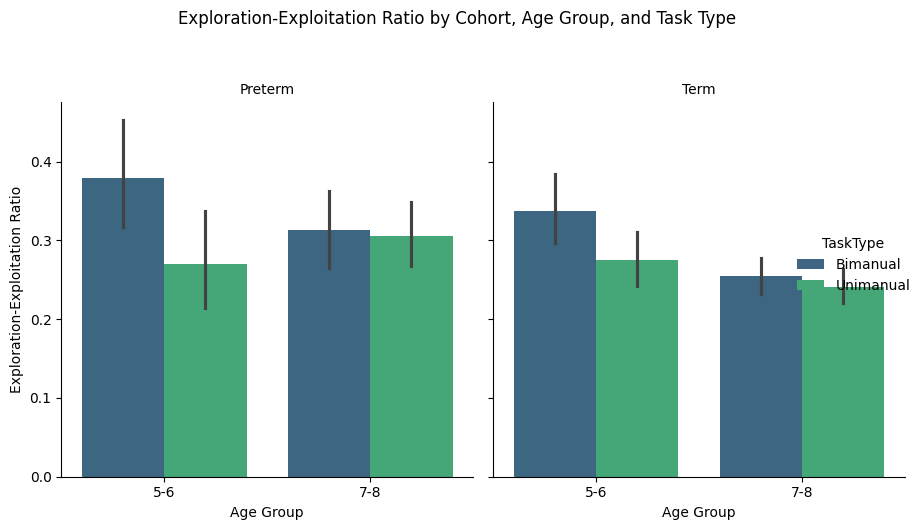

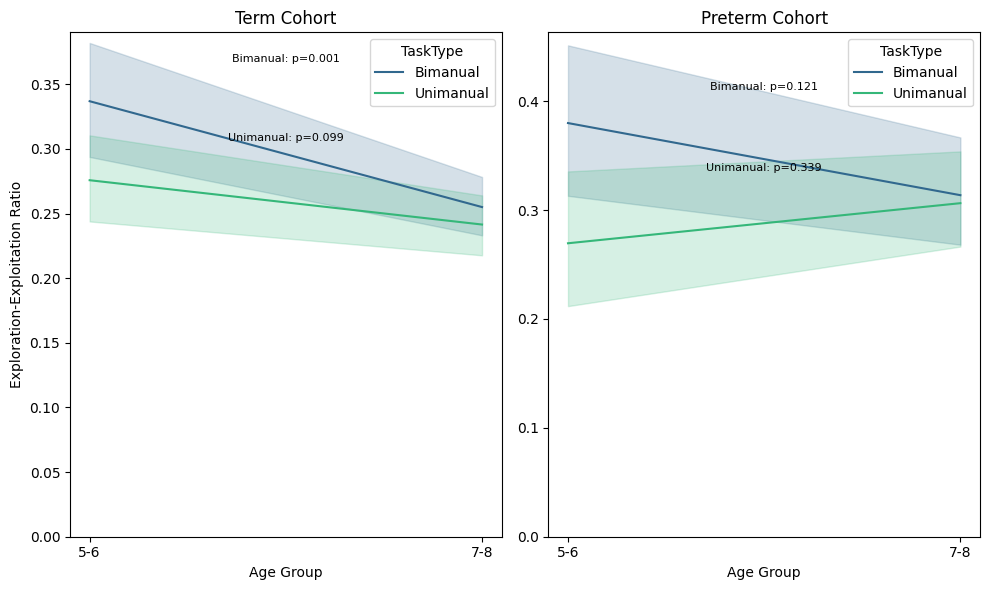

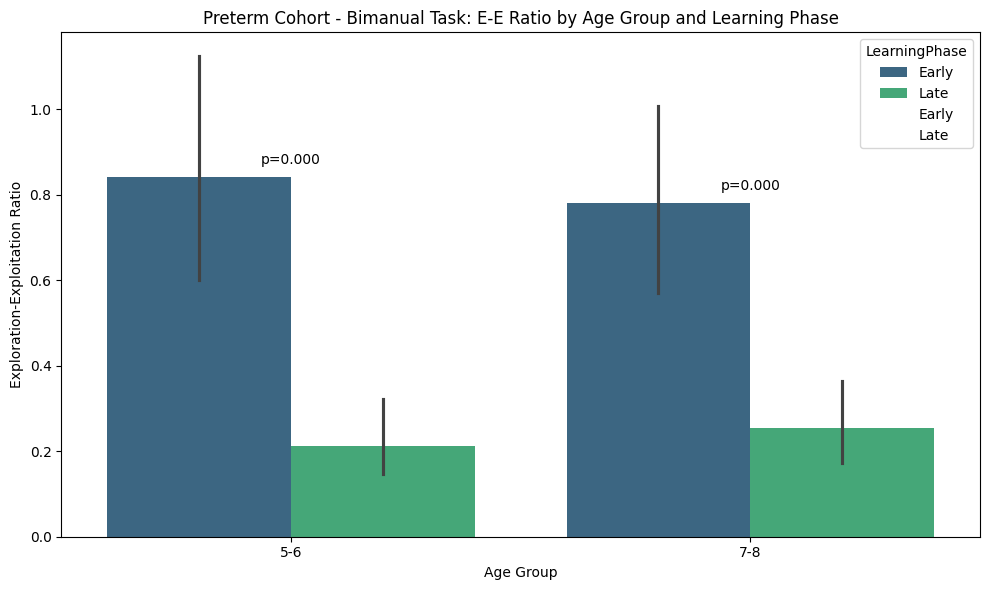

In [ ]:
# For general age group and task type analysis
results1 = analyze_ee_ratio_by_age_task_cohort(df_with_ratio_progress)

# For bimanual task early vs. late learning analysis
results2 = analyze_preterm_bimanual_early_vs_late(df_with_ratio_progress)

# Access statistics
print(results1["descriptive_stats"])
print(results1["t_test_results"])
print(results2["descriptive_stats"])
print(results2["t_test_results"])

# Display figures
# results1['figure'].show()
# results2['figure'].show()

In [ ]:
results1

{'descriptive_stats':     Cohort AgeGroup   TaskType      Mean       Std     N       SEM     CI_95  \
 0  Preterm      5-6  Unimanual  0.269474  0.910514   840  0.031416  0.061663   
 1  Preterm      5-6   Bimanual  0.379853  1.003573   840  0.034627  0.067965   
 2  Preterm      7-8  Unimanual  0.306283  0.806669  1320  0.022203  0.043557   
 3  Preterm      7-8   Bimanual  0.313621  0.909617  1320  0.025036  0.049115   
 4     Term      5-6  Unimanual  0.275799  0.834126  2280  0.017469  0.034257   
 5     Term      5-6   Bimanual  0.336918  1.073802  2280  0.022488  0.044100   
 6     Term      7-8  Unimanual  0.241515  0.689158  3720  0.011299  0.022153   
 7     Term      7-8   Bimanual  0.255028  0.722848  3720  0.011852  0.023236   
 
            Mean_CI  
 0  0.2695 ± 0.0617  
 1  0.3799 ± 0.0680  
 2  0.3063 ± 0.0436  
 3  0.3136 ± 0.0491  
 4  0.2758 ± 0.0343  
 5  0.3369 ± 0.0441  
 6  0.2415 ± 0.0222  
 7  0.2550 ± 0.0232  ,
 't_test_results':    Comparison_Type    Group_A 